# Notebook 08 — Flood Susceptibility Model

## Objective

Notebook 08 marks the transition from predictor preparation and statistical
diagnostics to supervised flood-susceptibility modelling.

The validated year-specific predictor datasets generated in Notebook 06 and
analysed in Notebook 07 will be used as the foundation for constructing and
evaluating the flood-susceptibility models for 2003, 2014, and 2025.

The major objectives of this notebook are:

1. Load and verify the final predictor datasets.
2. Prepare the flood-related target/reference data.
3. Construct the modelling datasets.
4. Define the predictor and target variables.
5. Establish an appropriate training and validation strategy.
6. Train the selected machine-learning / GeoAI models.
7. Evaluate and compare model performance.
8. Analyse predictor importance and model behaviour.
9. Generate flood-susceptibility predictions for 2003, 2014, and 2025.
10. Convert predictions into spatial susceptibility rasters.
11. Perform final model and raster quality assurance.
12. Inventory all Notebook 08 outputs.

Special attention will be given to spatial data leakage, categorical treatment
of LULC, temporal consistency, class balance, and reproducibility.

No modelling decision will be made solely from a single performance metric.
Model selection will be based on the complete validation evidence and the
research objectives.

Original predictor rasters and previously validated predictor tables will not
be modified during this notebook.

## 8.1 — Load and Verify Final Predictor Datasets

### Objective

The first step of the flood-susceptibility modelling workflow is to load the
final year-specific predictor tables generated and validated in Notebook 06.

The three modelling datasets correspond to:

- 2003
- 2014
- 2025

Each dataset contains the spatial identifiers, continuous environmental
predictors, rainfall, and categorical LULC information required for the
subsequent modelling workflow.

### Expected predictor structure

Each year-specific table is expected to contain:

- `year`
- `row`
- `col`
- `x_utm`
- `y_utm`
- `Elevation`
- `Slope`
- `Flow_Accumulation`
- `River_Distance`
- `Drainage_Density`
- `Clay`
- `Sand`
- `Rainfall`
- `LULC`

The predictor datasets were already subjected to structural and spatial QA
in Notebook 06. This step independently verifies that the expected files can
be loaded correctly before modelling begins.

### Verification performed

For each year, the following will be checked:

- File existence
- Number of observations
- Expected column structure
- Year identifier
- Missing values
- Infinite values
- Duplicate spatial cells
- Coordinate availability
- LULC class validity
- Numeric predictor availability

No predictor values will be modified, imputed, resampled, or transformed in
this step.

### Expected observation counts

| Year | Expected observations |
|------|-----------------------:|
| 2003 | 47,523 |
| 2014 | 46,391 |
| 2025 | 43,076 |

Successful completion of this step confirms that the final predictor
datasets are available as modelling inputs.

In [1]:
# ============================================================
# Step 08.1 — Load and Verify Final Predictor Datasets
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent


# ============================================================
# PATHS
# ============================================================

PREDICTOR_TABLE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "predictors_table"
)


PREDICTOR_FILES = {
    2003: PREDICTOR_TABLE_DIR / "predictors_2003_250m.csv",
    2025: PREDICTOR_TABLE_DIR / "predictors_2025_250m.csv",
}


EXPECTED_ROWS = {
    2003: 47523,
    2025: 43076,
}


EXPECTED_COLUMNS = [
    "year",
    "row",
    "col",
    "x_utm",
    "y_utm",
    "Elevation",
    "Slope",
    "Flow_Accumulation",
    "River_Distance",
    "Drainage_Density",
    "Clay",
    "Sand",
    "Rainfall",
    "LULC",
]


CONTINUOUS_PREDICTORS = [
    "Elevation",
    "Slope",
    "Flow_Accumulation",
    "River_Distance",
    "Drainage_Density",
    "Clay",
    "Sand",
    "Rainfall",
]


VALID_LULC_CLASSES = {
    1, 2, 3, 4, 5
}


# ============================================================
# LOAD DATASETS
# ============================================================

predictor_tables = {}


for year, file_path in PREDICTOR_FILES.items():

    print("\n" + "-" * 75)
    print(f"LOADING PREDICTOR TABLE — {year}")
    print("-" * 75)

    if not file_path.exists():
        raise FileNotFoundError(
            f"Predictor table not found for {year}:\n"
            f"{file_path}"
        )

    df = pd.read_csv(file_path)

    predictor_tables[year] = df

    print(
        f"File       : {file_path.name}"
    )

    print(
        f"Rows       : {len(df):,}"
    )

    print(
        f"Columns    : {len(df.columns)}"
    )


# ============================================================
# STRUCTURAL VERIFICATION
# ============================================================

print("\n" + "=" * 75)
print("STRUCTURAL VERIFICATION")
print("=" * 75)


for year, df in predictor_tables.items():

    print("\n" + "-" * 75)
    print(f"YEAR — {year}")
    print("-" * 75)

    # --------------------------------------------------------
    # Row count
    # --------------------------------------------------------

    expected_rows = EXPECTED_ROWS[year]

    assert len(df) == expected_rows, (
        f"{year}: expected {expected_rows:,} rows, "
        f"found {len(df):,}"
    )

    print(
        f"Rows              : "
        f"{len(df):,} "
        f"(expected {expected_rows:,}) ✓"
    )


    # --------------------------------------------------------
    # Column structure
    # --------------------------------------------------------

    actual_columns = list(df.columns)

    assert actual_columns == EXPECTED_COLUMNS, (
        f"{year}: unexpected column structure.\n"
        f"Expected: {EXPECTED_COLUMNS}\n"
        f"Found: {actual_columns}"
    )

    print(
        "Column structure   : ✓"
    )


    # --------------------------------------------------------
    # Year identifier
    # --------------------------------------------------------

    unique_years = df["year"].unique()

    assert len(unique_years) == 1
    assert int(unique_years[0]) == year

    print(
        f"Year identifier     : "
        f"{year} ✓"
    )


    # --------------------------------------------------------
    # Missing values
    # --------------------------------------------------------

    missing_count = int(
        df[EXPECTED_COLUMNS]
        .isna()
        .sum()
        .sum()
    )

    assert missing_count == 0, (
        f"{year}: {missing_count} missing values detected."
    )

    print(
        f"Missing values      : "
        f"{missing_count} ✓"
    )


    # --------------------------------------------------------
    # Infinite values
    # --------------------------------------------------------

    infinite_count = int(
        np.isinf(
            df[CONTINUOUS_PREDICTORS]
            .to_numpy(dtype=float)
        ).sum()
    )

    assert infinite_count == 0, (
        f"{year}: {infinite_count} infinite values detected."
    )

    print(
        f"Infinite values     : "
        f"{infinite_count} ✓"
    )


    # --------------------------------------------------------
    # Duplicate spatial cells
    # --------------------------------------------------------

    duplicate_cells = int(
        df.duplicated(
            subset=["row", "col"]
        ).sum()
    )

    assert duplicate_cells == 0, (
        f"{year}: duplicate spatial cells detected."
    )

    print(
        f"Duplicate cells     : "
        f"{duplicate_cells} ✓"
    )


    # --------------------------------------------------------
    # Coordinates
    # --------------------------------------------------------

    assert np.isfinite(
        df["x_utm"].to_numpy()
    ).all()

    assert np.isfinite(
        df["y_utm"].to_numpy()
    ).all()

    print(
        "Coordinates         : ✓"
    )


    # --------------------------------------------------------
    # LULC validity
    # --------------------------------------------------------

    lulc_classes = set(
        df["LULC"].astype(int).unique()
    )

    assert lulc_classes.issubset(
        VALID_LULC_CLASSES
    ), (
        f"{year}: invalid LULC classes detected: "
        f"{sorted(lulc_classes)}"
    )

    print(
        f"LULC classes        : "
        f"{sorted(lulc_classes)} ✓"
    )


    # --------------------------------------------------------
    # Continuous predictor availability
    # --------------------------------------------------------

    for predictor in CONTINUOUS_PREDICTORS:

        assert pd.api.types.is_numeric_dtype(
            df[predictor]
        ), (
            f"{year}: {predictor} is not numeric."
        )

    print(
        "Continuous predictors: ✓"
    )


# ============================================================
# DISPLAY DATA TYPES
# ============================================================

print("\n" + "=" * 75)
print("PREDICTOR DATA TYPES")
print("=" * 75)


for year, df in predictor_tables.items():

    print("\n" + "-" * 75)
    print(f"{year}")
    print("-" * 75)

    print(
        df.dtypes.to_string()
    )


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.1 — FINAL STATUS")
print("=" * 75)

print(
    "✓ 2003 predictor table loaded and verified"
)

print(
    "✓ 2025 predictor table loaded and verified"
)

print(
    "✓ Expected column structure confirmed"
)

print(
    "✓ Expected row counts confirmed"
)

print(
    "✓ Year identifiers confirmed"
)

print(
    "✓ No missing values detected"
)

print(
    "✓ No infinite values detected"
)

print(
    "✓ No duplicate spatial cells detected"
)

print(
    "✓ UTM coordinates are valid"
)

print(
    "✓ LULC classes are valid"
)

print(
    "✓ Continuous predictors are numeric"
)

print(
    "✓ Source predictor tables were not modified"
)

print("=" * 75)
print("✓ STEP 08.1 COMPLETED")
print("=" * 75)


---------------------------------------------------------------------------
LOADING PREDICTOR TABLE — 2003
---------------------------------------------------------------------------
File       : predictors_2003_250m.csv
Rows       : 47,523
Columns    : 14

---------------------------------------------------------------------------
LOADING PREDICTOR TABLE — 2025
---------------------------------------------------------------------------
File       : predictors_2025_250m.csv
Rows       : 43,076
Columns    : 14

STRUCTURAL VERIFICATION

---------------------------------------------------------------------------
YEAR — 2003
---------------------------------------------------------------------------
Rows              : 47,523 (expected 47,523) ✓
Column structure   : ✓
Year identifier     : 2003 ✓
Missing values      : 0 ✓
Infinite values     : 0 ✓
Duplicate cells     : 0 ✓
Coordinates         : ✓
LULC classes        : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] ✓
Con

# 08.2 — Flood Target / Reference Data Preparation

## Objective

This step prepares the flood reference data required for supervised
flood-susceptibility modelling.

The predictor datasets from Notebook 06 describe the environmental conditions
of each 250 m modelling cell. A supervised machine-learning model additionally
requires a target variable indicating whether a modelling cell represents a
flooded or non-flooded condition.

The flood reference data are therefore spatially associated with the common
250 m modelling grid and converted into a binary modelling target.

### Target definition

The target variable is defined as:

- `1` — Flood
- `0` — Non-flood

The target is kept separate from the environmental predictors. It is not
treated as an environmental predictor and is not used in the predictor
correlation or VIF analyses performed in Notebook 07.

### Operations performed

1. Load the flood reference dataset.
2. Verify its spatial reference and geometry.
3. Verify that the reference data spatially correspond to the study area.
4. Associate flood-reference information with the 250 m modelling cells.
5. Construct the binary flood target.
6. Examine flood and non-flood class counts.
7. Check for duplicate modelling cells.
8. Check for missing or invalid target values.
9. Preserve the spatial row/column identifiers required for later raster
   reconstruction.
10. Save the resulting flood-target table for subsequent modelling steps.

### Important methodological rule

No environmental predictor values are modified during this step.

No missing target values are imputed automatically.

The target construction procedure is explicitly recorded so that the
supervised-learning dataset can be reproduced and described in the research
paper.

The final output of this step will provide the flood/non-flood target that
will later be joined with the validated predictor datasets.


NOTEBOOK 08 — FLOOD REFERENCE DATA LOADING

---------------------------------------------------------------------------
FLOOD REFERENCE FILES — 2003
---------------------------------------------------------------------------
Directory : d:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2003
TIFF files: 1
  ✓ DFO_2279_From_20030715_to_20030901.tif

---------------------------------------------------------------------------
FLOOD REFERENCE FILES — 2025
---------------------------------------------------------------------------
Directory : d:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2025
TIFF files: 4
  ✓ AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.tif
  ✓ AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.tif
  ✓ AS_E030N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N024T3_20250812.tif
  ✓ AS_E030N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N027T3_20250812.tif

INITIAL FLOOD-REFERENCE IN

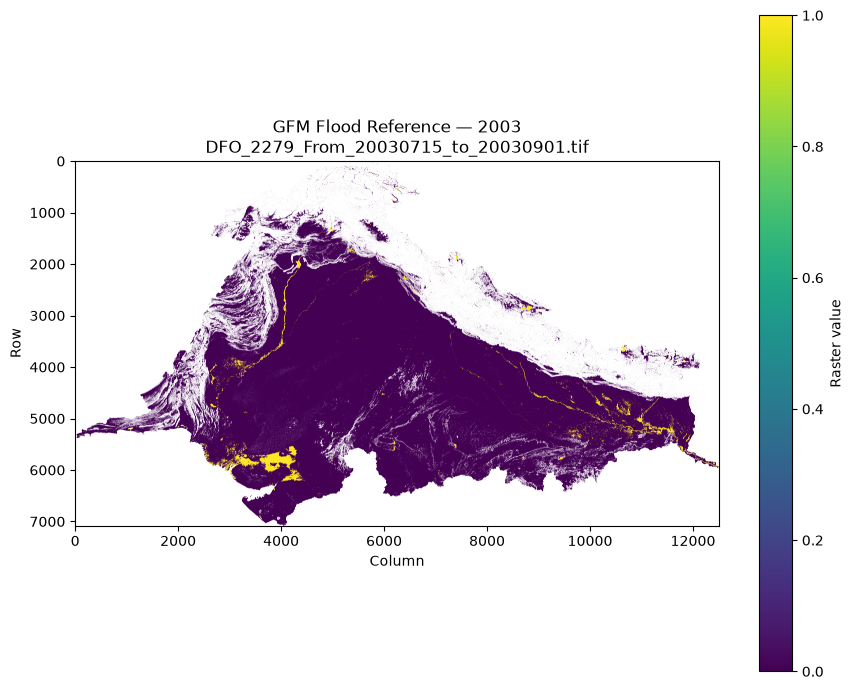

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2003_DFO_2279_From_20030715_to_20030901.png


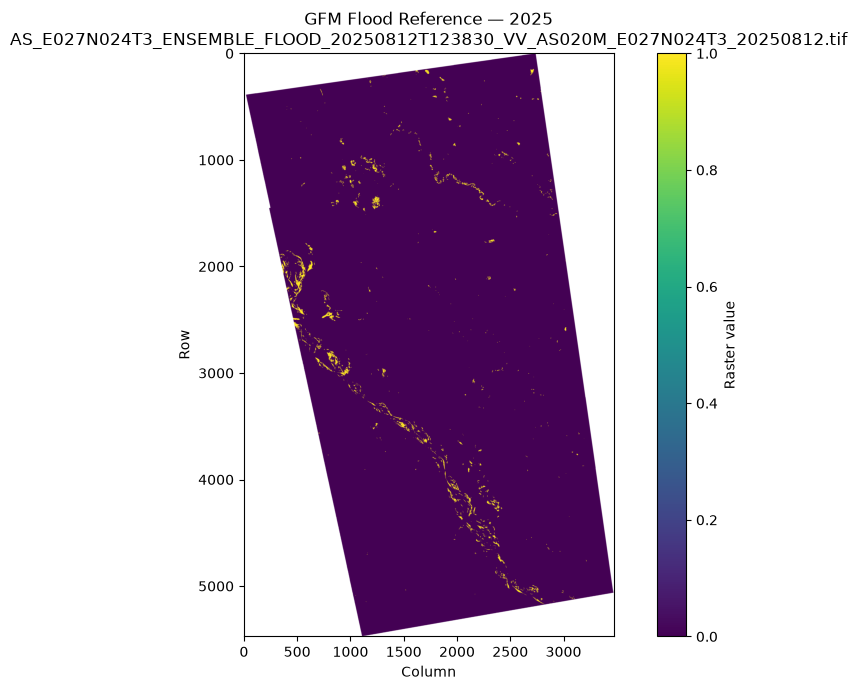

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2025_AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.png


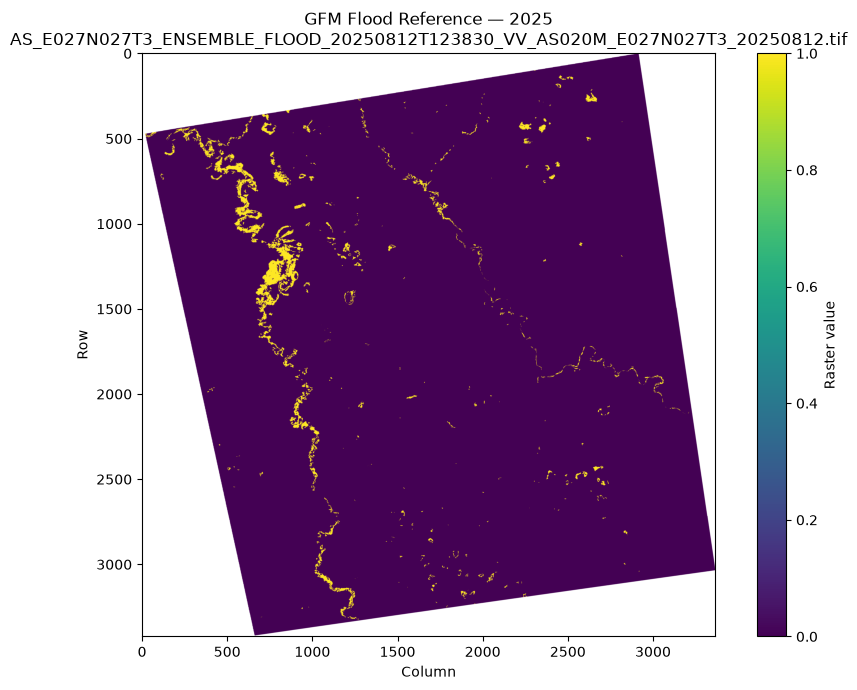

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2025_AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.png


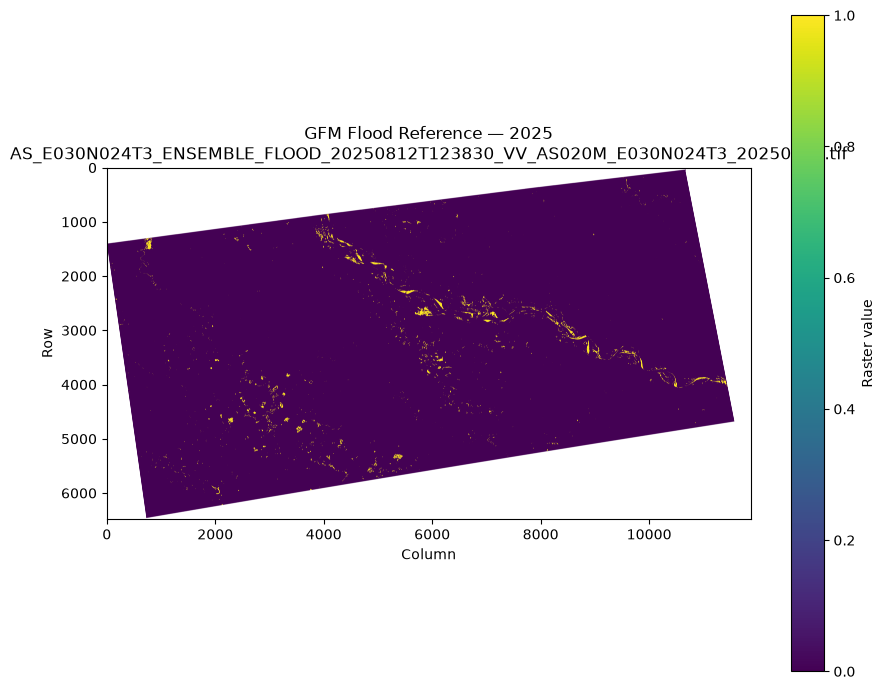

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2025_AS_E030N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N024T3_20250812.png


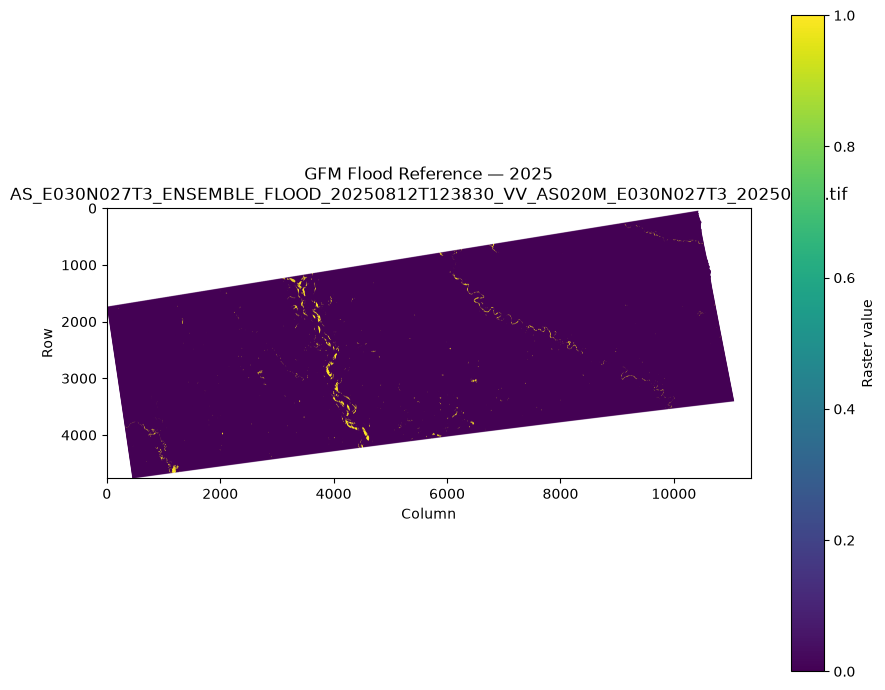

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2025_AS_E030N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N027T3_20250812.png

STEP 08.2 — FINAL STATUS
✓ Flood-reference directories located
✓ Flood-reference TIFF files discovered
✓ Raster metadata inspected
✓ CRS inspected
✓ Raster dimensions inspected
✓ Spatial resolution inspected
✓ NoData values inspected
✓ Valid and NoData cells counted
✓ Unique raster values inspected
✓ Initial raster visualisations generated
✓ Metadata table saved
✓ Unique-value table saved
✓ Raw flood-reference rasters were NOT modified
✓ No reprojection performed
✓ No resampling performed
✓ No clipping performed
✓ STEP 08.2 COMPLETED


In [2]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# Step 08.2 — Flood Reference Data Loading & Initial Inspection
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt


# ============================================================
# 1. PROJECT PATHS
# ============================================================

# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------
# If PROJECT_ROOT was already defined in previous notebooks,
# this will reuse it.
# Otherwise, set it manually to your project folder.
# ------------------------------------------------------------

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()

PROJECT_ROOT = Path(PROJECT_ROOT)


# ------------------------------------------------------------
# Raw flood-reference directories
# ------------------------------------------------------------

FLOOD_REFERENCE_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flood_reference"
)


YEAR_DIRECTORIES = {
    2003: FLOOD_REFERENCE_ROOT / "2003",
    2025: FLOOD_REFERENCE_ROOT / "2025",
}


# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "notebook_08"
)

TABLE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
)


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. FLOOD-REFERENCE FILE DISCOVERY
# ============================================================

print("\n" + "=" * 75)
print("NOTEBOOK 08 — FLOOD REFERENCE DATA LOADING")
print("=" * 75)


flood_files = {}


for year, year_dir in YEAR_DIRECTORIES.items():

    print("\n" + "-" * 75)
    print(f"FLOOD REFERENCE FILES — {year}")
    print("-" * 75)

    if not year_dir.exists():
        raise FileNotFoundError(
            f"Flood-reference directory not found:\n{year_dir}"
        )

    tif_files = sorted(
        list(year_dir.glob("*.tif"))
        + list(year_dir.glob("*.tiff"))
    )

    if len(tif_files) == 0:
        raise FileNotFoundError(
            f"No TIFF files found in:\n{year_dir}"
        )

    flood_files[year] = tif_files

    print(f"Directory : {year_dir}")
    print(f"TIFF files: {len(tif_files)}")

    for tif in tif_files:
        print(f"  ✓ {tif.name}")


# ============================================================
# 3. INITIAL RASTER METADATA INSPECTION
# ============================================================

metadata_records = []


for year, tif_files in flood_files.items():

    print("\n" + "=" * 75)
    print(f"INITIAL FLOOD-REFERENCE INSPECTION — {year}")
    print("=" * 75)

    for tif_path in tif_files:

        print("\n" + "-" * 75)
        print(f"FILE — {tif_path.name}")
        print("-" * 75)

        with rasterio.open(tif_path) as src:

            # ------------------------------------------------
            # Basic raster metadata
            # ------------------------------------------------

            width = src.width
            height = src.height
            count = src.count

            crs = src.crs

            resolution_x = src.res[0]
            resolution_y = src.res[1]

            transform = src.transform
            bounds = src.bounds

            dtype = src.dtypes[0]

            nodata = src.nodata

            driver = src.driver

            # ------------------------------------------------
            # Read first band
            # ------------------------------------------------

            data = src.read(1)

            # ------------------------------------------------
            # Valid mask
            # ------------------------------------------------

            if nodata is None:

                valid_mask = np.isfinite(data)

            else:

                valid_mask = (
                    np.isfinite(data)
                    & (data != nodata)
                )

            valid_values = data[valid_mask]

            valid_cells = int(
                valid_mask.sum()
            )

            total_cells = int(
                data.size
            )

            nodata_cells = (
                total_cells
                - valid_cells
            )

            # ------------------------------------------------
            # Unique values
            # ------------------------------------------------

            if valid_cells > 0:

                unique_values = np.unique(
                    valid_values
                )

                unique_display = (
                    unique_values[:50]
                )

                minimum = float(
                    np.min(valid_values)
                )

                maximum = float(
                    np.max(valid_values)
                )

            else:

                unique_values = np.array([])

                unique_display = []

                minimum = np.nan
                maximum = np.nan

            # ------------------------------------------------
            # Print metadata
            # ------------------------------------------------

            print(f"Driver          : {driver}")
            print(f"CRS             : {crs}")
            print(
                f"Dimensions      : "
                f"{height} × {width}"
            )

            print(
                f"Resolution      : "
                f"{resolution_x} × "
                f"{resolution_y}"
            )

            print(f"Bands           : {count}")

            print(f"Data type       : {dtype}")

            print(f"NoData          : {nodata}")

            print(
                f"Valid cells     : "
                f"{valid_cells:,} / "
                f"{total_cells:,}"
            )

            print(
                f"NoData cells    : "
                f"{nodata_cells:,}"
            )

            print(
                f"Minimum         : "
                f"{minimum}"
            )

            print(
                f"Maximum         : "
                f"{maximum}"
            )

            print(
                "Unique values   : "
                f"{unique_display}"
            )

            print(f"Bounds          : {bounds}")

            print(f"Transform       : {transform}")

            # ------------------------------------------------
            # Record metadata
            # ------------------------------------------------

            metadata_records.append({

                "year": year,

                "file_name":
                    tif_path.name,

                "width":
                    width,

                "height":
                    height,

                "bands":
                    count,

                "crs":
                    str(crs),

                "resolution_x":
                    resolution_x,

                "resolution_y":
                    resolution_y,

                "dtype":
                    dtype,

                "nodata":
                    nodata,

                "total_cells":
                    total_cells,

                "valid_cells":
                    valid_cells,

                "nodata_cells":
                    nodata_cells,

                "minimum":
                    minimum,

                "maximum":
                    maximum,

                "unique_value_count":
                    len(unique_values),

                "bounds_left":
                    bounds.left,

                "bounds_bottom":
                    bounds.bottom,

                "bounds_right":
                    bounds.right,

                "bounds_top":
                    bounds.top
            })


# ============================================================
# 4. METADATA SUMMARY TABLE
# ============================================================

metadata_df = pd.DataFrame(
    metadata_records
)


metadata_output = (
    TABLE_DIR
    / "notebook_08_flood_reference_metadata.csv"
)


metadata_df.to_csv(
    metadata_output,
    index=False
)


print("\n" + "=" * 75)
print("FLOOD-REFERENCE METADATA SUMMARY")
print("=" * 75)

print(
    metadata_df.to_string(
        index=False
    )
)

print(
    f"\n✓ Metadata table saved:\n"
    f"{metadata_output}"
)


# ============================================================
# 5. UNIQUE-VALUE INSPECTION
# ============================================================

print("\n" + "=" * 75)
print("FLOOD-REFERENCE VALUE INSPECTION")
print("=" * 75)


value_records = []


for year, tif_files in flood_files.items():

    for tif_path in tif_files:

        with rasterio.open(tif_path) as src:

            data = src.read(1)

            nodata = src.nodata

            if nodata is None:

                valid_mask = np.isfinite(data)

            else:

                valid_mask = (
                    np.isfinite(data)
                    & (data != nodata)
                )

            valid_values = data[valid_mask]

            unique_values, counts = np.unique(
                valid_values,
                return_counts=True
            )

            print("\n" + "-" * 75)
            print(f"{year} — {tif_path.name}")
            print("-" * 75)

            for value, count in zip(
                unique_values,
                counts
            ):

                percentage = (
                    count
                    / len(valid_values)
                    * 100
                )

                print(
                    f"Value {value}"
                    f" : {count:,} cells"
                    f" | {percentage:.4f}%"
                )

                value_records.append({

                    "year": year,

                    "file_name":
                        tif_path.name,

                    "value":
                        float(value),

                    "cell_count":
                        int(count),

                    "percentage":
                        float(percentage)
                })


value_df = pd.DataFrame(
    value_records
)


value_output = (
    TABLE_DIR
    / "notebook_08_flood_reference_unique_values.csv"
)


value_df.to_csv(
    value_output,
    index=False
)


print(
    f"\n✓ Unique-value table saved:\n"
    f"{value_output}"
)


# ============================================================
# 6. QUICK VISUAL INSPECTION
# ============================================================
#
# This is ONLY a visual inspection.
#
# No raster is modified.
# No reprojection is performed.
# No resampling is performed.
# No clipping is performed.
#
# For multiple 2025 tiles, each tile is plotted separately.
# ============================================================

print("\n" + "=" * 75)
print("FLOOD-REFERENCE VISUAL INSPECTION")
print("=" * 75)


figure_records = []


for year, tif_files in flood_files.items():

    for tif_path in tif_files:

        with rasterio.open(tif_path) as src:

            data = src.read(1)

            nodata = src.nodata

            if nodata is not None:

                display_data = np.ma.masked_equal(
                    data,
                    nodata
                )

            else:

                display_data = np.ma.masked_invalid(
                    data
                )

            fig, ax = plt.subplots(
                figsize=(9, 7)
            )

            image = ax.imshow(
                display_data
            )

            ax.set_title(
                f"GFM Flood Reference — {year}\n"
                f"{tif_path.name}"
            )

            ax.set_xlabel(
                "Column"
            )

            ax.set_ylabel(
                "Row"
            )

            fig.colorbar(
                image,
                ax=ax,
                label="Raster value"
            )

            plt.tight_layout()

            figure_name = (
                f"flood_reference_"
                f"{year}_"
                f"{tif_path.stem}.png"
            )

            figure_path = (
                FIGURE_DIR
                / figure_name
            )

            fig.savefig(
                figure_path,
                dpi=300,
                bbox_inches="tight"
            )

            plt.show()

            plt.close(fig)

            figure_records.append({

                "year": year,

                "file_name":
                    tif_path.name,

                "figure":
                    str(figure_path)
            })

            print(
                f"✓ Figure saved:\n"
                f"{figure_path}"
            )


# ============================================================
# 7. FINAL STEP 08.2 STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.2 — FINAL STATUS")
print("=" * 75)

print(
    "✓ Flood-reference directories located"
)

print(
    "✓ Flood-reference TIFF files discovered"
)

print(
    "✓ Raster metadata inspected"
)

print(
    "✓ CRS inspected"
)

print(
    "✓ Raster dimensions inspected"
)

print(
    "✓ Spatial resolution inspected"
)

print(
    "✓ NoData values inspected"
)

print(
    "✓ Valid and NoData cells counted"
)

print(
    "✓ Unique raster values inspected"
)

print(
    "✓ Initial raster visualisations generated"
)

print(
    "✓ Metadata table saved"
)

print(
    "✓ Unique-value table saved"
)

print(
    "✓ Raw flood-reference rasters were NOT modified"
)

print(
    "✓ No reprojection performed"
)

print(
    "✓ No resampling performed"
)

print(
    "✓ No clipping performed"
)

print("=" * 75)
print("✓ STEP 08.2 COMPLETED")
print("=" * 75)

# Step 08.3 — Flood Reference Raster Quality Assurance

## Objective

This step performs quality assurance on the raw flood-reference rasters for
2003, 2014, and 2025 before any spatial transformation or integration with
the predictor datasets.

The purpose is to verify that the downloaded flood-reference datasets have
valid and interpretable raster structures and that the 2025 multi-tile GFM
products are internally consistent.

## Quality Checks

The following properties are assessed:

- Coordinate reference system (CRS)
- Raster dimensions
- Spatial resolution
- Number of bands
- Data type
- NoData definition
- Valid-cell counts
- Raster spatial bounds
- Unique raster values
- Flood/non-flood value structure
- Within-year consistency of 2025 GFM tiles

## Important methodological rule

The raw flood-reference rasters are treated as source/reference data.

Therefore:

- No raster values are modified.
- No missing values are imputed.
- No clipping is performed.
- No reprojection is performed.
- No resampling is performed.
- No mosaicking is performed.
- No flood class is manually recoded at this stage.

Any required spatial harmonisation will be performed in a subsequent step.

## Expected Outcome

The step should establish whether each flood-reference raster is suitable
for subsequent spatial harmonisation and conversion into the flood target
variable required for machine-learning modelling.

**Step 08.3 does not train any machine-learning model.**

In [3]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# Step 08.3 — Flood Reference Raster Quality Assurance
# ============================================================

import numpy as np
import pandas as pd
import rasterio


# ============================================================
# 1. VERIFY FLOOD FILES FROM STEP 08.2
# ============================================================

print("\n" + "=" * 75)
print("NOTEBOOK 08 — FLOOD REFERENCE RASTER QA")
print("=" * 75)

if "flood_files" not in globals():
    raise RuntimeError(
        "flood_files was not found. "
        "Run Step 08.2 before Step 08.3."
    )


# ============================================================
# 2. EXPECTED FLOOD-REFERENCE YEARS
# ============================================================

EXPECTED_YEARS = [2003, 2025]

for year in EXPECTED_YEARS:

    if year not in flood_files:
        raise ValueError(
            f"Flood-reference files for {year} were not loaded."
        )

    if len(flood_files[year]) == 0:
        raise ValueError(
            f"No flood-reference TIFFs found for {year}."
        )


print("\n✓ Flood-reference years detected:")
print("  2003")
print("  2025")


# ============================================================
# 3. RASTER-LEVEL QA
# ============================================================

qa_records = []


for year in EXPECTED_YEARS:

    print("\n" + "=" * 75)
    print(f"YEAR — {year}")
    print("=" * 75)

    for tif_path in flood_files[year]:

        print("\n" + "-" * 75)
        print(f"FILE — {tif_path.name}")
        print("-" * 75)

        with rasterio.open(tif_path) as src:

            # ------------------------------------------------
            # Metadata
            # ------------------------------------------------

            width = src.width
            height = src.height
            band_count = src.count

            crs = src.crs
            dtype = src.dtypes[0]
            nodata = src.nodata

            res_x = src.res[0]
            res_y = src.res[1]

            bounds = src.bounds
            transform = src.transform

            # ------------------------------------------------
            # Read first band
            # ------------------------------------------------

            data = src.read(1)

            # ------------------------------------------------
            # Valid-data mask
            # ------------------------------------------------

            if nodata is None:

                valid_mask = np.isfinite(data)

            else:

                valid_mask = (
                    np.isfinite(data)
                    & (data != nodata)
                )

            valid_values = data[valid_mask]

            total_cells = data.size
            valid_cells = int(valid_mask.sum())
            nodata_cells = (
                total_cells - valid_cells
            )

            # ------------------------------------------------
            # Unique values
            # ------------------------------------------------

            if valid_cells > 0:

                unique_values, counts = np.unique(
                    valid_values,
                    return_counts=True
                )

            else:

                unique_values = np.array([])
                counts = np.array([])

            # ------------------------------------------------
            # Flood value detection
            #
            # We DO NOT recode anything.
            # We only report whether value 1 exists.
            # ------------------------------------------------

            contains_zero = (
                0 in unique_values
            )

            contains_one = (
                1 in unique_values
            )

            contains_other_values = any(
                value not in [0, 1]
                for value in unique_values
            )

            # ------------------------------------------------
            # Flood-cell count if binary 0/1
            # ------------------------------------------------

            if contains_one:

                flood_cells = int(
                    np.sum(valid_values == 1)
                )

            else:

                flood_cells = 0

            if valid_cells > 0:

                flood_percentage = (
                    flood_cells
                    / valid_cells
                    * 100
                )

            else:

                flood_percentage = np.nan

            # ------------------------------------------------
            # QA flags
            # ------------------------------------------------

            dimensions_valid = (
                width > 0
                and height > 0
            )

            band_valid = (
                band_count == 1
            )

            resolution_valid = (
                res_x > 0
                and res_y > 0
            )

            valid_data_exists = (
                valid_cells > 0
            )

            binary_values = (
                valid_cells > 0
                and all(
                    value in [0, 1]
                    for value in unique_values
                )
            )

            # ------------------------------------------------
            # Print results
            # ------------------------------------------------

            print(
                f"CRS              : {crs}"
            )

            print(
                f"Dimensions        : "
                f"{height} × {width}"
            )

            print(
                f"Bands             : {band_count}"
            )

            print(
                f"Data type         : {dtype}"
            )

            print(
                f"Resolution        : "
                f"{res_x} × {res_y}"
            )

            print(
                f"NoData            : {nodata}"
            )

            print(
                f"Total cells       : "
                f"{total_cells:,}"
            )

            print(
                f"Valid cells       : "
                f"{valid_cells:,}"
            )

            print(
                f"NoData cells      : "
                f"{nodata_cells:,}"
            )

            print(
                f"Unique values     : "
                f"{unique_values}"
            )

            print(
                f"Contains 0        : "
                f"{contains_zero}"
            )

            print(
                f"Contains 1        : "
                f"{contains_one}"
            )

            print(
                f"Contains other    : "
                f"{contains_other_values}"
            )

            print(
                f"Binary 0/1        : "
                f"{binary_values}"
            )

            print(
                f"Flood cells (1)   : "
                f"{flood_cells:,}"
            )

            print(
                f"Flood share       : "
                f"{flood_percentage:.4f}%"
            )

            print(
                f"Bounds            : "
                f"{bounds}"
            )

            # ------------------------------------------------
            # Store QA record
            # ------------------------------------------------

            qa_records.append({

                "year":
                    year,

                "file_name":
                    tif_path.name,

                "width":
                    width,

                "height":
                    height,

                "bands":
                    band_count,

                "crs":
                    str(crs),

                "dtype":
                    dtype,

                "resolution_x":
                    res_x,

                "resolution_y":
                    res_y,

                "nodata":
                    nodata,

                "total_cells":
                    total_cells,

                "valid_cells":
                    valid_cells,

                "nodata_cells":
                    nodata_cells,

                "unique_value_count":
                    len(unique_values),

                "unique_values":
                    ",".join(
                        str(v)
                        for v in unique_values
                    ),

                "contains_zero":
                    contains_zero,

                "contains_one":
                    contains_one,

                "contains_other_values":
                    contains_other_values,

                "binary_0_1":
                    binary_values,

                "flood_cells_value_1":
                    flood_cells,

                "flood_percentage":
                    flood_percentage,

                "bounds_left":
                    bounds.left,

                "bounds_bottom":
                    bounds.bottom,

                "bounds_right":
                    bounds.right,

                "bounds_top":
                    bounds.top,

                "dimensions_valid":
                    dimensions_valid,

                "single_band":
                    band_valid,

                "resolution_valid":
                    resolution_valid,

                "valid_data_exists":
                    valid_data_exists
            })


# ============================================================
# 4. QA TABLE
# ============================================================

qa_df = pd.DataFrame(
    qa_records
)


qa_output = (
    TABLE_DIR
    / "notebook_08_flood_reference_raster_QA.csv"
)


qa_df.to_csv(
    qa_output,
    index=False
)


print("\n" + "=" * 75)
print("FLOOD REFERENCE RASTER QA SUMMARY")
print("=" * 75)

print(
    qa_df[
        [
            "year",
            "file_name",
            "crs",
            "width",
            "height",
            "bands",
            "resolution_x",
            "resolution_y",
            "dtype",
            "nodata",
            "unique_values",
            "binary_0_1",
            "flood_cells_value_1",
            "flood_percentage"
        ]
    ].to_string(index=False)
)

print(
    f"\n✓ QA table saved:\n"
    f"{qa_output}"
)


# ============================================================
# 5. WITHIN-YEAR CONSISTENCY CHECK — 2025
# ============================================================
#
# 2025 contains multiple GFM tiles.
#
# We check whether all tiles share:
# - CRS
# - resolution
# - band count
# - data type
#
# We do NOT require identical dimensions or bounds because
# different tiles naturally cover different spatial areas.
# ============================================================

print("\n" + "=" * 75)
print("2025 GFM TILE CONSISTENCY CHECK")
print("=" * 75)


gfm_2025 = qa_df[
    qa_df["year"] == 2025
].copy()


if len(gfm_2025) == 0:

    raise ValueError(
        "No 2025 flood-reference tiles found."
    )


crs_consistent = (
    gfm_2025["crs"].nunique() == 1
)

resolution_x_consistent = (
    gfm_2025["resolution_x"].nunique() == 1
)

resolution_y_consistent = (
    gfm_2025["resolution_y"].nunique() == 1
)

band_consistent = (
    gfm_2025["bands"].nunique() == 1
)

dtype_consistent = (
    gfm_2025["dtype"].nunique() == 1
)


print(
    f"CRS consistency        : "
    f"{crs_consistent}"
)

print(
    f"X-resolution consistency: "
    f"{resolution_x_consistent}"
)

print(
    f"Y-resolution consistency: "
    f"{resolution_y_consistent}"
)

print(
    f"Band-count consistency  : "
    f"{band_consistent}"
)

print(
    f"Data-type consistency   : "
    f"{dtype_consistent}"
)


gfm_consistent = all([
    crs_consistent,
    resolution_x_consistent,
    resolution_y_consistent,
    band_consistent,
    dtype_consistent
])


if gfm_consistent:

    print(
        "\n✓ 2025 GFM tiles are internally "
        "consistent in raster structure."
    )

else:

    print(
        "\n⚠ 2025 GFM tiles require further "
        "investigation before mosaicking."
    )


# ============================================================
# 6. VALUE-STRUCTURE QA
# ============================================================

print("\n" + "=" * 75)
print("FLOOD VALUE STRUCTURE QA")
print("=" * 75)


all_binary = qa_df["binary_0_1"].all()


print(
    f"All rasters binary 0/1 : "
    f"{all_binary}"
)


if all_binary:

    print(
        "✓ All valid raster values are "
        "restricted to 0 and 1."
    )

else:

    print(
        "⚠ One or more rasters contain "
        "values other than 0 and 1."
    )

    print(
        "Do NOT recode them yet."
    )


# ============================================================
# 7. FINAL QA STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.3 — FINAL STATUS")
print("=" * 75)

print(
    "✓ Raw flood-reference rasters inspected"
)

print(
    "✓ Raster dimensions verified"
)

print(
    "✓ Band counts verified"
)

print(
    "✓ CRS inspected"
)

print(
    "✓ Spatial resolution inspected"
)

print(
    "✓ Data types inspected"
)

print(
    "✓ NoData values inspected"
)

print(
    "✓ Spatial bounds inspected"
)

print(
    "✓ Unique raster values inspected"
)

print(
    "✓ Flood-value presence assessed"
)

print(
    "✓ Flood-cell counts calculated"
)

print(
    "✓ Flood percentage calculated"
)

print(
    "✓ 2025 GFM tile consistency assessed"
)

print(
    "✓ QA results saved as CSV"
)

print(
    "✓ No raster was modified"
)

print(
    "✓ No values were recoded"
)

print(
    "✓ No clipping performed"
)

print(
    "✓ No reprojection performed"
)

print(
    "✓ No resampling performed"
)

print(
    "✓ No mosaicking performed"
)

print("=" * 75)
print("✓ STEP 08.3 COMPLETED")
print("=" * 75)


NOTEBOOK 08 — FLOOD REFERENCE RASTER QA

✓ Flood-reference years detected:
  2003
  2025

YEAR — 2003

---------------------------------------------------------------------------
FILE — DFO_2279_From_20030715_to_20030901.tif
---------------------------------------------------------------------------
CRS              : EPSG:4326
Dimensions        : 7080 × 12506
Bands             : 5
Data type         : float32
Resolution        : 0.002245788210298804 × 0.002245788210298804
NoData            : None
Total cells       : 88,542,480
Valid cells       : 29,640,663
NoData cells      : 58,901,817
Unique values     : [0. 1.]
Contains 0        : True
Contains 1        : True
Contains other    : False
Binary 0/1        : True
Flood cells (1)   : 764,407
Flood share       : 2.5789%
Bounds            : BoundingBox(left=61.664852678384555, bottom=21.19799491701041, right=89.7506800363814, top=37.09817544592594)

YEAR — 2025

---------------------------------------------------------------------------

# Step 08.4 — Flood Reference Band Identification & Semantic QA

## Objective

The flood-reference datasets obtained from different sources may contain
different numbers of raster bands and different data structures.

The 2003 and 2014 flood-reference rasters contain multiple bands, whereas
the 2025 GFM products contain a single band.

Before constructing the flood target variable, this step identifies and
documents the semantic meaning and numerical structure of each raster band.

## Checks Performed

For every flood-reference TIFF:

- Number of bands
- Band descriptions
- Band metadata/tags
- Data type
- NoData value
- Minimum and maximum values
- Unique values
- Valid-cell count
- Binary/non-binary structure

## Important methodological rule

No assumption is made that Band 1 represents flood extent.

The flood-reference band will only be selected after its metadata and
numerical structure have been inspected.

No raster values are modified in this step.

No reprojection, resampling, clipping, mosaicking, or recoding is performed.

## Expected Outcome

The step will establish:

1. The meaning of each available raster band.
2. Which band should be used as the flood-reference variable for 2003.
3. Which band should be used for 2014.
4. The structure of the single-band 2025 GFM products.

This information is required before spatial harmonisation and construction
of the machine-learning target variable.

In [4]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# Step 08.4 — Flood Reference Band Identification & Semantic QA
# ============================================================

import numpy as np
import pandas as pd
import rasterio


# ============================================================
# 1. VERIFY INPUTS FROM STEP 08.2
# ============================================================

print("\n" + "=" * 75)
print("NOTEBOOK 08 — FLOOD REFERENCE BAND IDENTIFICATION")
print("=" * 75)

if "flood_files" not in globals():
    raise RuntimeError(
        "flood_files was not found. "
        "Run Step 08.2 before Step 08.4."
    )


# ============================================================
# 2. BAND-LEVEL INSPECTION
# ============================================================

band_records = []


for year in sorted(flood_files.keys()):

    print("\n" + "=" * 75)
    print(f"YEAR — {year}")
    print("=" * 75)

    for tif_path in flood_files[year]:

        print("\n" + "-" * 75)
        print(f"FILE — {tif_path.name}")
        print("-" * 75)

        with rasterio.open(tif_path) as src:

            print(f"Number of bands : {src.count}")
            print(f"CRS             : {src.crs}")
            print(f"Data types      : {src.dtypes}")
            print(f"NoData          : {src.nodatavals}")

            # ------------------------------------------------
            # Dataset-level tags
            # ------------------------------------------------

            dataset_tags = src.tags()

            if dataset_tags:

                print("\nDataset tags:")

                for key, value in dataset_tags.items():

                    print(
                        f"  {key}: {value}"
                    )

            else:

                print(
                    "\nDataset tags: None"
                )

            # ------------------------------------------------
            # Inspect every band
            # ------------------------------------------------

            for band_number in range(
                1,
                src.count + 1
            ):

                print("\n" + "-" * 60)
                print(
                    f"BAND {band_number}"
                )
                print("-" * 60)

                # --------------------------------------------
                # Band description
                # --------------------------------------------

                description = (
                    src.descriptions[
                        band_number - 1
                    ]
                )

                print(
                    f"Description : "
                    f"{description}"
                )

                # --------------------------------------------
                # Band-specific tags
                # --------------------------------------------

                band_tags = src.tags(
                    band_number
                )

                if band_tags:

                    print("Band tags:")

                    for key, value in band_tags.items():

                        print(
                            f"  {key}: {value}"
                        )

                else:

                    print(
                        "Band tags: None"
                    )

                # --------------------------------------------
                # Read band
                # --------------------------------------------

                data = src.read(
                    band_number
                )

                nodata = src.nodatavals[
                    band_number - 1
                ]

                # --------------------------------------------
                # Valid mask
                # --------------------------------------------

                if nodata is None:

                    valid_mask = (
                        np.isfinite(data)
                    )

                else:

                    valid_mask = (
                        np.isfinite(data)
                        & (data != nodata)
                    )

                valid_values = data[
                    valid_mask
                ]

                valid_cells = int(
                    valid_mask.sum()
                )

                total_cells = int(
                    data.size
                )

                # --------------------------------------------
                # Statistics
                # --------------------------------------------

                if valid_cells > 0:

                    minimum = float(
                        np.min(valid_values)
                    )

                    maximum = float(
                        np.max(valid_values)
                    )

                    mean = float(
                        np.mean(valid_values)
                    )

                    unique_values = np.unique(
                        valid_values
                    )

                else:

                    minimum = np.nan
                    maximum = np.nan
                    mean = np.nan

                    unique_values = np.array([])

                # --------------------------------------------
                # Determine whether binary
                # --------------------------------------------

                is_binary_01 = (
                    valid_cells > 0
                    and np.all(
                        np.isin(
                            unique_values,
                            [0, 1]
                        )
                    )
                )

                # --------------------------------------------
                # Count 0 and 1
                # --------------------------------------------

                zero_count = int(
                    np.sum(
                        valid_values == 0
                    )
                )

                one_count = int(
                    np.sum(
                        valid_values == 1
                    )
                )

                # --------------------------------------------
                # Print statistics
                # --------------------------------------------

                print(
                    f"Data type   : "
                    f"{src.dtypes[band_number - 1]}"
                )

                print(
                    f"NoData      : "
                    f"{nodata}"
                )

                print(
                    f"Total cells : "
                    f"{total_cells:,}"
                )

                print(
                    f"Valid cells : "
                    f"{valid_cells:,}"
                )

                print(
                    f"Minimum     : "
                    f"{minimum}"
                )

                print(
                    f"Maximum     : "
                    f"{maximum}"
                )

                print(
                    f"Mean        : "
                    f"{mean}"
                )

                print(
                    f"Unique count: "
                    f"{len(unique_values)}"
                )

                print(
                    f"Unique values: "
                    f"{unique_values[:50]}"
                )

                print(
                    f"Zero cells  : "
                    f"{zero_count:,}"
                )

                print(
                    f"One cells   : "
                    f"{one_count:,}"
                )

                print(
                    f"Binary 0/1  : "
                    f"{is_binary_01}"
                )

                # --------------------------------------------
                # Store record
                # --------------------------------------------

                band_records.append({

                    "year":
                        year,

                    "file_name":
                        tif_path.name,

                    "band":
                        band_number,

                    "description":
                        description,

                    "dtype":
                        src.dtypes[
                            band_number - 1
                        ],

                    "nodata":
                        nodata,

                    "total_cells":
                        total_cells,

                    "valid_cells":
                        valid_cells,

                    "minimum":
                        minimum,

                    "maximum":
                        maximum,

                    "mean":
                        mean,

                    "unique_value_count":
                        len(unique_values),

                    "unique_values":
                        ",".join(
                            str(v)
                            for v in unique_values[:100]
                        ),

                    "zero_cells":
                        zero_count,

                    "one_cells":
                        one_count,

                    "binary_0_1":
                        is_binary_01
                })


# ============================================================
# 3. SAVE BAND INVENTORY
# ============================================================

band_df = pd.DataFrame(
    band_records
)


band_output = (
    TABLE_DIR
    / "notebook_08_flood_reference_band_inventory.csv"
)


band_df.to_csv(
    band_output,
    index=False
)


print("\n" + "=" * 75)
print("BAND INVENTORY")
print("=" * 75)

print(
    band_df.to_string(
        index=False
    )
)

print(
    f"\n✓ Band inventory saved:\n"
    f"{band_output}"
)


# ============================================================
# 4. SUMMARY BY YEAR
# ============================================================

print("\n" + "=" * 75)
print("BAND STRUCTURE SUMMARY")
print("=" * 75)


for year in sorted(
    band_df["year"].unique()
):

    year_df = band_df[
        band_df["year"] == year
    ]

    print("\n" + "-" * 75)
    print(f"{year}")
    print("-" * 75)

    print(
        f"Files : "
        f"{year_df['file_name'].nunique()}"
    )

    print(
        f"Bands : "
        f"{year_df['band'].nunique()}"
    )

    print(
        year_df[
            [
                "file_name",
                "band",
                "description",
                "dtype",
                "minimum",
                "maximum",
                "unique_value_count",
                "binary_0_1"
            ]
        ].to_string(
            index=False
        )
    )


# ============================================================
# 5. CHECK FOR BAND DESCRIPTIONS
# ============================================================

print("\n" + "=" * 75)
print("BAND DESCRIPTION CHECK")
print("=" * 75)


missing_descriptions = band_df[
    band_df["description"].isna()
    | (
        band_df["description"]
        .astype(str)
        .str.strip()
        .isin(
            ["", "None"]
        )
    )
]


if len(missing_descriptions) == 0:

    print(
        "✓ All bands have descriptions."
    )

else:

    print(
        f"⚠ {len(missing_descriptions)} "
        "bands have no explicit description."
    )

    print(
        missing_descriptions[
            [
                "year",
                "file_name",
                "band"
            ]
        ].to_string(
            index=False
        )
    )


# ============================================================
# 6. BINARY BAND SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("BINARY BAND SUMMARY")
print("=" * 75)


binary_df = band_df[
    band_df["binary_0_1"] == True
].copy()


if len(binary_df) > 0:

    print(
        binary_df[
            [
                "year",
                "file_name",
                "band",
                "description",
                "zero_cells",
                "one_cells"
            ]
        ].to_string(
            index=False
        )
    )

else:

    print(
        "No binary 0/1 bands detected."
    )


# ============================================================
# 7. IMPORTANT: DO NOT SELECT FLOOD BAND AUTOMATICALLY
# ============================================================

print("\n" + "=" * 75)
print("FLOOD BAND SELECTION")
print("=" * 75)

print(
    "⚠ Flood-reference bands have NOT been selected automatically."
)

print(
    "⚠ Band 1 is NOT assumed to be the flood mask."
)

print(
    "The band meaning must be confirmed from the "
    "source-product metadata/documentation before "
    "constructing the flood target."
)


# ============================================================
# 8. FINAL STEP 08.4 STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.4 — FINAL STATUS")
print("=" * 75)

print(
    "✓ Every flood-reference band inspected"
)

print(
    "✓ Band descriptions inspected"
)

print(
    "✓ Dataset-level metadata inspected"
)

print(
    "✓ Band-level metadata inspected"
)

print(
    "✓ Data types inspected"
)

print(
    "✓ NoData values inspected"
)

print(
    "✓ Valid-cell counts calculated"
)

print(
    "✓ Minimum and maximum values calculated"
)

print(
    "✓ Unique values inspected"
)

print(
    "✓ Binary 0/1 structure assessed"
)

print(
    "✓ Band inventory saved"
)

print(
    "✓ No raster values modified"
)

print(
    "✓ No band was automatically selected"
)

print(
    "✓ No reprojection performed"
)

print(
    "✓ No resampling performed"
)

print(
    "✓ No clipping performed"
)

print(
    "✓ No mosaicking performed"
)

print("=" * 75)
print(
    "✓ STEP 08.4 COMPLETED — "
    "BAND INVENTORY READY FOR INTERPRETATION"
)
print("=" * 75)


NOTEBOOK 08 — FLOOD REFERENCE BAND IDENTIFICATION

YEAR — 2003

---------------------------------------------------------------------------
FILE — DFO_2279_From_20030715_to_20030901.tif
---------------------------------------------------------------------------
Number of bands : 5
CRS             : EPSG:4326
Data types      : ('float32', 'float32', 'float32', 'float32', 'float32')
NoData          : (None, None, None, None, None)

Dataset tags:
  AREA_OR_POINT: Area

------------------------------------------------------------
BAND 1
------------------------------------------------------------
Description : flooded
Band tags: None
Data type   : float32
NoData      : None
Total cells : 88,542,480
Valid cells : 29,640,663
Minimum     : 0.0
Maximum     : 1.0
Mean        : 0.025789132341742516
Unique count: 2
Unique values: [0. 1.]
Zero cells  : 28,876,256
One cells   : 764,407
Binary 0/1  : True

------------------------------------------------------------
BAND 2
-------------------------

## Step 08.5 — Flood Reference Spatial Harmonisation

The observed flood-reference datasets for 2003 and 2025 originate from different raster products and therefore differ in coordinate reference system, spatial resolution, extent, and grid alignment. To make them compatible with the predictor datasets, both flood references are transformed to a common modelling grid.

The target grid uses EPSG:32644 and a 250 m × 250 m spatial resolution, consistent with the harmonised predictor datasets. The common grid is constructed from the full study-area extent using an outward rounding rule so that the complete study area is covered.

Flood labels are aggregated using a maximum-value rule rather than continuous interpolation. Thus, a target cell is labelled as flooded when at least one valid source flood pixel within that cell is classified as flooded. Source NoData is kept separate from confirmed non-flood observations.

The resulting 2003 and 2025 flood-reference rasters therefore have identical CRS, resolution, extent, dimensions, and pixel alignment while retaining the binary flood/non-flood structure.

In [5]:
# ============================================================
# 08.5 — FLOOD REFERENCE SPATIAL HARMONISATION
# PATH SETUP
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# Detect project root
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR


# ------------------------------------------------------------
# Input / output paths
# ------------------------------------------------------------

FLOOD_REFERENCE_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flood_reference"
)

FLOOD_OUTPUT_ROOT = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_08"
    / "flood_reference"
)

FLOOD_OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


TABLE_OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "notebook_08"
)

TABLE_OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 75)
print("PROJECT PATH CHECK")
print("=" * 75)

print("Current directory      :", CURRENT_DIR)
print("Detected project root  :", PROJECT_ROOT)
print("Flood-reference input  :", FLOOD_REFERENCE_ROOT)
print("Flood-reference output :", FLOOD_OUTPUT_ROOT)
print("Table output            :", TABLE_OUTPUT_ROOT)

PROJECT PATH CHECK
Current directory      : D:\Projects\GeoAI-Flood-Susceptibility\notebooks
Detected project root  : D:\Projects\GeoAI-Flood-Susceptibility
Flood-reference input  : D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference
Flood-reference output : D:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_08\flood_reference
Table output            : D:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\notebook_08


## 2014 Flood Reference Assessment and Exclusion

An intermediate 2014 flood-reference dataset was investigated to support the temporal analysis. Available DFO and India Flood Inventory (IFI) records were evaluated, followed by Landsat 8-based pre-flood and flood-period spectral change analysis. However, the evaluated sources did not provide sufficiently reliable spatial evidence to construct a defensible 2014 flood-reference mask. The Landsat-derived candidate inundation areas showed substantial fragmentation, weak spatial association with the Gomti River corridor, and sensitivity near cloud/shadow boundaries. Therefore, 2014 was excluded from supervised flood-susceptibility model training. The 2014 investigation outputs are retained as documentation of the data-screening process.

In [6]:
# ============================================================
# FINAL MODELING YEARS
# ============================================================

MODELING_YEARS = [2003, 2025]

print(
    "Flood-reference modeling years:",
    MODELING_YEARS
)

Flood-reference modeling years: [2003, 2025]


In [7]:
# ============================================================
# FLOOD-REFERENCE INPUT FILES
# ============================================================

flood_reference_files = {

    2003: [
        FLOOD_REFERENCE_ROOT
        / "2003"
        / "DFO_2279_From_20030715_to_20030901.tif"
    ],

    2025: [
        FLOOD_REFERENCE_ROOT
        / "2025"
        / "AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.tif",

        FLOOD_REFERENCE_ROOT
        / "2025"
        / "AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.tif",

        FLOOD_REFERENCE_ROOT
        / "2025"
        / "AS_E030N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N024T3_20250812.tif",

        FLOOD_REFERENCE_ROOT
        / "2025"
        / "AS_E030N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N027T3_20250812.tif"
    ]
}


print("=" * 75)
print("INPUT FLOOD-REFERENCE FILE CHECK")
print("=" * 75)

for year, files in flood_reference_files.items():

    print(f"\nYEAR — {year}")

    for path in files:

        print(path)

        if path.exists():
            print("  ✓ File exists")
        else:
            print("  ✗ FILE NOT FOUND")

INPUT FLOOD-REFERENCE FILE CHECK

YEAR — 2003
D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2003\DFO_2279_From_20030715_to_20030901.tif
  ✓ File exists

YEAR — 2025
D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2025\AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.tif
  ✓ File exists
D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2025\AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.tif
  ✓ File exists
D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2025\AS_E030N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N024T3_20250812.tif
  ✓ File exists
D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2025\AS_E030N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N027T3_20250812.tif
  ✓ File exists


In [12]:
# ============================================================
# COMMON 250 m MODELLING GRID
# ============================================================
from rasterio.transform import from_origin
import geopandas as gpd 
TARGET_CRS = "EPSG:32644"
TARGET_RESOLUTION = 250.0


# ------------------------------------------------------------
# Reproject study area to target CRS
# ------------------------------------------------------------
study_area = PROJECT_ROOT/ "data" / "processed"/ "notebook_01"/ "Lucknow_Search_Area_20km.gpkg"
study_area = gpd.read_file(study_area)
study_area_utm = study_area.set_crs(TARGET_CRS)


# ------------------------------------------------------------
# Full study-area bounds
# ------------------------------------------------------------

xmin, ymin, xmax, ymax = (
    study_area_utm.total_bounds
)


# ------------------------------------------------------------
# Outward rounding
#
# floor() expands the grid outward on the left/bottom.
# ceil() expands the grid outward on the right/top.
# ------------------------------------------------------------

grid_xmin = (
    np.floor(xmin / TARGET_RESOLUTION)
    * TARGET_RESOLUTION
)

grid_ymin = (
    np.floor(ymin / TARGET_RESOLUTION)
    * TARGET_RESOLUTION
)

grid_xmax = (
    np.ceil(xmax / TARGET_RESOLUTION)
    * TARGET_RESOLUTION
)

grid_ymax = (
    np.ceil(ymax / TARGET_RESOLUTION)
    * TARGET_RESOLUTION
)


# ------------------------------------------------------------
# Dimensions
# ------------------------------------------------------------

grid_width = int(
    round(
        (grid_xmax - grid_xmin)
        / TARGET_RESOLUTION
    )
)

grid_height = int(
    round(
        (grid_ymax - grid_ymin)
        / TARGET_RESOLUTION
    )
)


# ------------------------------------------------------------
# Transform
# ------------------------------------------------------------

grid_transform = from_origin(
    grid_xmin,
    grid_ymax,
    TARGET_RESOLUTION,
    TARGET_RESOLUTION
)


print("=" * 75)
print("COMMON MODELLING GRID")
print("=" * 75)

print(f"CRS              : {TARGET_CRS}")
print(
    f"Resolution       : "
    f"{TARGET_RESOLUTION:.2f} × "
    f"{TARGET_RESOLUTION:.2f} m"
)

print(f"Width            : {grid_width}")
print(f"Height           : {grid_height}")
print(
    f"Total cells      : "
    f"{grid_width * grid_height:,}"
)

print(f"Left             : {grid_xmin:.2f}")
print(f"Bottom           : {grid_ymin:.2f}")
print(f"Right            : {grid_xmax:.2f}")
print(f"Top              : {grid_ymax:.2f}")

print("\nStudy-area bounds:")
print(
    f"Left             : {xmin:.2f}"
)
print(
    f"Bottom           : {ymin:.2f}"
)
print(
    f"Right            : {xmax:.2f}"
)
print(
    f"Top              : {ymax:.2f}"
)

COMMON MODELLING GRID
CRS              : EPSG:32644
Resolution       : 250.00 × 250.00 m
Width            : 252
Height           : 244
Total cells      : 61,488
Left             : 463250.00
Bottom           : 2938000.00
Right            : 526250.00
Top              : 2999000.00

Study-area bounds:
Left             : 463358.58
Bottom           : 2938218.33
Right            : 526062.36
Top              : 2998994.25


In [ ]:
# ============================================================
# VERIFY STUDY-AREA COVERAGE
# ============================================================

grid_right_covers_study = (
    grid_xmax >= xmax
)

grid_left_covers_study = (
    grid_xmin <= xmin
)

grid_top_covers_study = (
    grid_ymax >= ymax
)

grid_bottom_covers_study = (
    grid_ymin <= ymin
)


print("=" * 75)
print("COMMON GRID COVERAGE CHECK")
print("=" * 75)

print(
    "Left coverage   :",
    grid_left_covers_study
)

print(
    "Right coverage  :",
    grid_right_covers_study
)

print(
    "Bottom coverage :",
    grid_bottom_covers_study
)

print(
    "Top coverage    :",
    grid_top_covers_study
)


assert grid_left_covers_study
assert grid_right_covers_study
assert grid_bottom_covers_study
assert grid_top_covers_study

print(
    "\n✓ Common grid fully covers "
    "the study-area extent."
)

COMMON GRID COVERAGE CHECK
Left coverage   : True
Right coverage  : True
Bottom coverage : True
Top coverage    : True

✓ Common grid fully covers the study-area extent.


In [14]:
# ============================================================
# STUDY-AREA MASK ON COMMON GRID
# ============================================================
from rasterio.features import rasterize
study_area_mask = rasterize(
    [
        (geom, 1)
        for geom in study_area_utm.geometry
    ],
    out_shape=(
        grid_height,
        grid_width
    ),
    transform=grid_transform,
    fill=0,
    dtype="uint8",
    all_touched=False
)


print("=" * 75)
print("STUDY-AREA MASK")
print("=" * 75)

print(
    "Grid cells inside study area:",
    np.count_nonzero(study_area_mask)
)

print(
    "Grid cells outside study area:",
    np.count_nonzero(
        study_area_mask == 0
    )
)

STUDY-AREA MASK
Grid cells inside study area: 47730
Grid cells outside study area: 13758


In [15]:
# ============================================================
# FUNCTION — HARMONISE A SINGLE BINARY FLOOD RASTER
# ============================================================

def harmonize_binary_flood_raster(
    source_path,
    target_crs,
    target_transform,
    target_shape
):
    """
    Reproject a binary flood raster to the common grid.

    Flood presence is preserved using maximum aggregation.
    Source NoData is kept separate from confirmed non-flood.
    """

    with rasterio.open(source_path) as src:

        source = src.read(1).astype(np.float32)

        source_crs = src.crs
        source_transform = src.transform
        source_nodata = src.nodata

        # ----------------------------------------------------
        # Source valid mask
        # ----------------------------------------------------

        if source_nodata is not None:

            source_valid = (
                source != source_nodata
            )

        else:

            source_valid = (
                np.isfinite(source)
            )

        # ----------------------------------------------------
        # Binary flood mask
        # ----------------------------------------------------

        source_flood = np.zeros(
            source.shape,
            dtype=np.uint8
        )

        source_flood[
            source_valid
            & (source > 0)
        ] = 1

        # ----------------------------------------------------
        # Reproject flood presence
        #
        # Maximum preserves flood presence.
        # ----------------------------------------------------

        flood_target = np.zeros(
            target_shape,
            dtype=np.uint8
        )

        reproject(
            source=source_flood,
            destination=flood_target,
            src_transform=source_transform,
            src_crs=source_crs,
            dst_transform=target_transform,
            dst_crs=target_crs,
            resampling=Resampling.max,
            src_nodata=0,
            dst_nodata=0
        )

        # ----------------------------------------------------
        # Reproject source validity separately
        # ----------------------------------------------------

        valid_target = np.zeros(
            target_shape,
            dtype=np.uint8
        )

        reproject(
            source=source_valid.astype(np.uint8),
            destination=valid_target,
            src_transform=source_transform,
            src_crs=source_crs,
            dst_transform=target_transform,
            dst_crs=target_crs,
            resampling=Resampling.max,
            src_nodata=0,
            dst_nodata=0
        )

        valid_target = (
            valid_target > 0
        )

        # ----------------------------------------------------
        # Construct final target
        #
        # 0 = confirmed valid non-flood
        # 1 = flood
        # 255 = NoData
        # ----------------------------------------------------

        target = np.full(
            target_shape,
            255,
            dtype=np.uint8
        )

        target[
            valid_target
        ] = flood_target[
            valid_target
        ]

        return (
            target,
            source_valid,
            source_flood
        )

## Step 08.5.8 — 2003 DFO Source-Band Inspection

Before spatial harmonisation, the 2003 DFO flood-reference raster is inspected to identify the appropriate flood-information band and distinguish flood, non-flood, and NoData values. This prevents an incorrect band or invalid source values from being propagated into the common 250 m modelling grid.

No source raster is modified during this inspection.

In [16]:
# ============================================================
# 08.5.8 — 2003 DFO SOURCE-BAND INSPECTION
# ============================================================

dfo_2003_path = flood_reference_files[2003][0]

print("=" * 75)
print("2003 DFO SOURCE-BAND INSPECTION")
print("=" * 75)

with rasterio.open(dfo_2003_path) as src:

    print(f"File       : {src.name}")
    print(f"CRS        : {src.crs}")
    print(f"Dimensions : {src.width} × {src.height}")
    print(f"Count      : {src.count}")
    print(f"Data types : {src.dtypes}")
    print(f"NoData     : {src.nodata}")
    print(f"Transform  : {src.transform}")

    print("\nBand descriptions:")
    
    for band_number in range(1, src.count + 1):

        description = src.descriptions[band_number - 1]

        print(
            f"  Band {band_number}: "
            f"{description}"
        )

2003 DFO SOURCE-BAND INSPECTION
File       : D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2003\DFO_2279_From_20030715_to_20030901.tif
CRS        : EPSG:4326
Dimensions : 12506 × 7080
Count      : 5
Data types : ('float32', 'float32', 'float32', 'float32', 'float32')
NoData     : None
Transform  : | 0.00, 0.00, 61.66|
| 0.00,-0.00, 37.10|
| 0.00, 0.00, 1.00|

Band descriptions:
  Band 1: flooded
  Band 2: duration
  Band 3: clear_views
  Band 4: clear_perc
  Band 5: jrc_perm_water


In [ ]:
# ============================================================
# 08.5.9 — DFO UNIQUE-VALUE INSPECTION
# ============================================================

print("=" * 75)
print("2003 DFO UNIQUE VALUES BY BAND")
print("=" * 75)

dfo_band_records = []

with rasterio.open(dfo_2003_path) as src:

    nodata = src.nodata

    for band_number in range(1, src.count + 1):

        data = src.read(band_number)

        if nodata is not None:
            valid_data = data[data != nodata]
        else:
            valid_data = data[np.isfinite(data)]

        unique_values = np.unique(valid_data)

        print("\n" + "-" * 75)
        print(f"BAND {band_number}")
        print("-" * 75)

        print(
            "Number of valid cells:",
            valid_data.size
        )

        print(
            "Number of unique values:",
            unique_values.size
        )

        print(
            "Minimum:",
            np.min(valid_data)
        )

        print(
            "Maximum:",
            np.max(valid_data)
        )

        if unique_values.size <= 20:

            print(
                "Unique values:",
                unique_values
            )

        else:

            print(
                "First 20 unique values:",
                unique_values[:20]
            )

        dfo_band_records.append({
            "band": band_number,
            "valid_cells": valid_data.size,
            "unique_value_count": unique_values.size,
            "minimum": np.min(valid_data),
            "maximum": np.max(valid_data)
        })


dfo_band_summary = pd.DataFrame(
    dfo_band_records
)

display(dfo_band_summary)

2003 DFO UNIQUE VALUES BY BAND

---------------------------------------------------------------------------
BAND 1
---------------------------------------------------------------------------
Number of valid cells: 29640663
Number of unique values: 2
Minimum: 0.0
Maximum: 1.0
Unique values: [0. 1.]

---------------------------------------------------------------------------
BAND 2
---------------------------------------------------------------------------
Number of valid cells: 29640663
Number of unique values: 53
Minimum: 0.0
Maximum: 52.0
First 20 unique values: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19.]

---------------------------------------------------------------------------
BAND 3
---------------------------------------------------------------------------
Number of valid cells: 29640663
Number of unique values: 26
Minimum: 81.0
Maximum: 106.0
First 20 unique values: [ 81.  82.  83.  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.
  9

,band,valid_cells,unique_value_count,minimum,maximum
0,1,29640663,2,0.000000,1.0
1,2,29640663,53,0.000000,52.0
2,3,29640663,26,81.000000,106.0
3,4,29640663,181,0.783019,1.0
4,5,41481939,2,0.000000,1.0


## Step 08.5.10 — 2003 DFO Flood-Band Spatial Inspection

Band 1 (`flooded`) is the selected 2003 DFO flood-reference band because it contains binary flood information with values 0 and 1.

This step verifies the spatial distribution of the flood and non-flood pixels before harmonisation to the common 250 m modelling grid. The source raster is not modified.

In [17]:
# ============================================================
# 08.5.10 — 2003 DFO FLOOD-BAND SPATIAL INSPECTION
# ============================================================

with rasterio.open(dfo_2003_path) as src:
    flooded = src.read(1)

    print("=" * 75)
    print("2003 DFO FLOOD BAND INSPECTION")
    print("=" * 75)

    print(f"Band used        : Band 1")
    print(f"Description      : {src.descriptions[0]}")
    print(f"CRS              : {src.crs}")
    print(f"Dimensions       : {src.width} × {src.height}")
    print(f"Resolution       : {src.res}")
    print(f"Bounds           : {src.bounds}")

    # Because the source has no declared NoData value,
    # use finite values as the validity criterion.
    valid_mask = np.isfinite(flooded)

    flood_mask = valid_mask & (flooded == 1)
    nonflood_mask = valid_mask & (flooded == 0)

    print("\nSource pixel counts")
    print("-" * 75)
    print(f"Valid cells       : {valid_mask.sum():,}")
    print(f"Flood cells       : {flood_mask.sum():,}")
    print(f"Non-flood cells   : {nonflood_mask.sum():,}")
    print(f"Invalid cells     : {(~valid_mask).sum():,}")

    print("\nFlood proportion among valid cells")
    print("-" * 75)
    print(f"{100 * flood_mask.sum() / valid_mask.sum():.4f}%")

2003 DFO FLOOD BAND INSPECTION
Band used        : Band 1
Description      : flooded
CRS              : EPSG:4326
Dimensions       : 12506 × 7080
Resolution       : (0.002245788210298804, 0.002245788210298804)
Bounds           : BoundingBox(left=61.664852678384555, bottom=21.19799491701041, right=89.7506800363814, top=37.09817544592594)

Source pixel counts
---------------------------------------------------------------------------
Valid cells       : 29,640,663
Flood cells       : 764,407
Non-flood cells   : 28,876,256
Invalid cells     : 58,901,817

Flood proportion among valid cells
---------------------------------------------------------------------------
2.5789%


## Step 08.5.11 — 2003 DFO Flood and Validity Masks

The verified `flooded` band is converted into two explicit source masks: a flood mask and a valid-data mask. Flood pixels are defined as valid Band 1 cells with value 1, while valid non-flood pixels have value 0.

Separating flood status from source validity is necessary because the DFO raster has no declared NoData value but contains non-finite cells. These masks will be used during spatial harmonisation to prevent invalid source areas from being interpreted as non-flood or flood observations.

In [18]:
# ============================================================
# 08.5.11 — 2003 DFO FLOOD + VALIDITY MASKS
# ============================================================

with rasterio.open(dfo_2003_path) as src:
    dfo_2003_band1 = src.read(1).astype("float32")

    source_transform = src.transform
    source_crs = src.crs
    source_shape = dfo_2003_band1.shape

# ------------------------------------------------------------
# Explicit source validity and flood masks
# ------------------------------------------------------------

dfo_2003_valid = np.isfinite(dfo_2003_band1)
dfo_2003_flood = dfo_2003_valid & (dfo_2003_band1 == 1)
dfo_2003_nonflood = dfo_2003_valid & (dfo_2003_band1 == 0)

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

print("=" * 75)
print("2003 DFO SOURCE MASK CHECK")
print("=" * 75)

print(f"Source shape          : {source_shape}")
print(f"Valid cells           : {dfo_2003_valid.sum():,}")
print(f"Flood cells           : {dfo_2003_flood.sum():,}")
print(f"Non-flood cells       : {dfo_2003_nonflood.sum():,}")
print(f"Invalid cells         : {(~dfo_2003_valid).sum():,}")

print("\nConsistency checks")
print("-" * 75)

print(
    "Flood + non-flood = valid:",
    np.array_equal(
        dfo_2003_flood | dfo_2003_nonflood,
        dfo_2003_valid
    )
)

print(
    "Flood ∩ non-flood = empty:",
    not np.any(dfo_2003_flood & dfo_2003_nonflood)
)

print(
    "Unexpected valid values:",
    np.sum(
        dfo_2003_valid &
        ~((dfo_2003_band1 == 0) | (dfo_2003_band1 == 1))
    )
)

2003 DFO SOURCE MASK CHECK
Source shape          : (7080, 12506)
Valid cells           : 29,640,663
Flood cells           : 764,407
Non-flood cells       : 28,876,256
Invalid cells         : 58,901,817

Consistency checks
---------------------------------------------------------------------------
Flood + non-flood = valid: True
Flood ∩ non-flood = empty: True
Unexpected valid values: 0


## Step 08.5.12 — 2003 DFO Flood Reference Harmonisation

The verified 2003 DFO flood mask is harmonised to the common 250 m modelling grid.

Because the DFO source resolution is finer than the target grid, aggregation is performed using two separate source masks:

1. a valid-data mask, indicating whether a target cell contains any valid DFO observation;
2. a flood mask, indicating whether a target cell contains any observed flood pixel.

A target cell is labelled as flooded when at least one valid source pixel within it is classified as flood. A target cell with valid DFO observations but no flood observations is labelled non-flood. Cells without any valid DFO observation remain NoData.

This prevents source NoData/invalid areas from being incorrectly interpreted as non-flood or flood.

In [19]:
# ============================================================
# 08.5.12 — 2003 DFO → COMMON 250 m GRID
# ============================================================

from rasterio.warp import reproject, Resampling
from rasterio.transform import from_origin

# ------------------------------------------------------------
# Explicit definition of the corrected common modelling grid
# ------------------------------------------------------------

target_crs = "EPSG:32644"

target_resolution = 250.0

target_width = 252
target_height = 244

target_left = 463250.0
target_bottom = 2938000.0
target_right = 526250.0
target_top = 2999000.0

target_transform = from_origin(
    target_left,
    target_top,
    target_resolution,
    target_resolution
)

print("=" * 75)
print("COMMON 250 m TARGET GRID")
print("=" * 75)

print(f"CRS              : {target_crs}")
print(f"Resolution       : {target_resolution} × {target_resolution} m")
print(f"Dimensions       : {target_width} × {target_height}")
print(f"Total cells      : {target_width * target_height:,}")
print(f"Left             : {target_left}")
print(f"Bottom           : {target_bottom}")
print(f"Right            : {target_right}")
print(f"Top              : {target_top}")

# ------------------------------------------------------------
# Create destination arrays
# ------------------------------------------------------------

valid_fraction = np.zeros(
    (target_height, target_width),
    dtype="float32"
)

flood_fraction = np.zeros(
    (target_height, target_width),
    dtype="float32"
)

# ------------------------------------------------------------
# Reproject and aggregate source masks
# ------------------------------------------------------------

with rasterio.open(dfo_2003_path) as src:

    # Source validity:
    # 1 = valid DFO observation
    # 0 = invalid/non-finite
    source_valid = dfo_2003_valid.astype("uint8")

    # Source flood:
    # 1 = flood
    # 0 = non-flood OR invalid
    source_flood = dfo_2003_flood.astype("uint8")

    # --------------------------------------------------------
    # Aggregate VALID mask
    # --------------------------------------------------------

    reproject(
        source=source_valid,
        destination=valid_fraction,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=target_transform,
        dst_crs=target_crs,
        resampling=Resampling.average
    )

    # --------------------------------------------------------
    # Aggregate FLOOD mask
    # --------------------------------------------------------

    reproject(
        source=source_flood,
        destination=flood_fraction,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=target_transform,
        dst_crs=target_crs,
        resampling=Resampling.average
    )

# ------------------------------------------------------------
# Convert aggregated fractions into categorical labels
#
# -1 = NoData
#  0 = Non-flood
#  1 = Flood
# ------------------------------------------------------------

dfo_2003_harmonized = np.full(
    (target_height, target_width),
    -1,
    dtype="int8"
)

target_has_valid = valid_fraction > 0
target_has_flood = flood_fraction > 0

# Valid target cells containing at least one flood source pixel
dfo_2003_harmonized[
    target_has_valid & target_has_flood
] = 1

# Valid target cells containing no flood source pixels
dfo_2003_harmonized[
    target_has_valid & ~target_has_flood
] = 0

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("HARMONISED 2003 FLOOD REFERENCE")
print("=" * 75)

flood_count = np.sum(dfo_2003_harmonized == 1)
nonflood_count = np.sum(dfo_2003_harmonized == 0)
nodata_count = np.sum(dfo_2003_harmonized == -1)

print(f"Flood cells     : {flood_count:,}")
print(f"Non-flood cells : {nonflood_count:,}")
print(f"NoData cells    : {nodata_count:,}")
print(f"Total cells     : {dfo_2003_harmonized.size:,}")

valid_target_count = flood_count + nonflood_count

if valid_target_count > 0:
    flood_percentage = (
        100 * flood_count / valid_target_count
    )

    print(
        f"\nFlood proportion among valid target cells: "
        f"{flood_percentage:.4f}%"
    )

COMMON 250 m TARGET GRID
CRS              : EPSG:32644
Resolution       : 250.0 × 250.0 m
Dimensions       : 252 × 244
Total cells      : 61,488
Left             : 463250.0
Bottom           : 2938000.0
Right            : 526250.0
Top              : 2999000.0

HARMONISED 2003 FLOOD REFERENCE
Flood cells     : 184
Non-flood cells : 61,304
NoData cells    : 0
Total cells     : 61,488

Flood proportion among valid target cells: 0.2992%


## Step 08.5.13 — Apply Study-Area Mask to 2003 Flood Reference

The harmonised 2003 DFO flood reference is restricted to the final Lucknow + 20 km study area.

Cells whose pixel centres fall inside the study-area geometry retain their harmonised flood/non-flood labels. Cells outside the study area are assigned NoData.

This ensures that flood labels outside the defined modelling region cannot enter the supervised learning dataset.

In [22]:
# ============================================================
# 08.5.13 — APPLY STUDY-AREA MASK
# ============================================================

print("=" * 75)
print("APPLYING STUDY-AREA MASK — 2003")
print("=" * 75)

target_crs = "EPSG:32644"

# Reproject study area to target grid CRS if necessary
study_area_target = study_area.set_crs(target_crs)

# ------------------------------------------------------------
# Create pixel-centre coordinates for the common grid
# ------------------------------------------------------------

rows, cols = np.indices(
    (target_height, target_width)
)

xs, ys = rasterio.transform.xy(
    target_transform,
    rows,
    cols,
    offset="center"
)

xs = np.asarray(xs)
ys = np.asarray(ys)

# ------------------------------------------------------------
# Convert pixel centres into GeoDataFrame
# ------------------------------------------------------------

pixel_points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(
        xs.ravel(),
        ys.ravel()
    ),
    crs=target_crs
)

# ------------------------------------------------------------
# Determine which pixel centres fall inside the study area
# ------------------------------------------------------------

study_area_union = study_area_target.geometry.union_all()

study_mask = (
    pixel_points.geometry.within(study_area_union)
    .to_numpy()
    .reshape(target_height, target_width)
)

# ------------------------------------------------------------
# Apply mask
#
# -1 = NoData / outside study area
#  0 = Non-flood
#  1 = Flood
# ------------------------------------------------------------

dfo_2003_study_area = np.full(
    (target_height, target_width),
    -1,
    dtype="int8"
)

dfo_2003_study_area[
    study_mask
] = dfo_2003_harmonized[
    study_mask
]

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

flood_count = np.sum(dfo_2003_study_area == 1)
nonflood_count = np.sum(dfo_2003_study_area == 0)
nodata_count = np.sum(dfo_2003_study_area == -1)
inside_count = flood_count + nonflood_count

print("\n" + "=" * 75)
print("2003 STUDY-AREA FLOOD REFERENCE")
print("=" * 75)

print(f"Flood cells inside study area     : {flood_count:,}")
print(f"Non-flood cells inside study area : {nonflood_count:,}")
print(f"NoData / outside study area       : {nodata_count:,}")
print(f"Total grid cells                  : {dfo_2003_study_area.size:,}")

print("\nStudy-area coverage")
print("-" * 75)

print(
    f"Cells inside study area           : "
    f"{inside_count:,}"
)

print(
    f"Cells outside study area          : "
    f"{nodata_count:,}"
)

print(
    f"Study-area cell proportion        : "
    f"{100 * inside_count / dfo_2003_study_area.size:.2f}%"
)

print("\nFlood statistics inside study area")
print("-" * 75)

if inside_count > 0:

    flood_percentage = (
        100 * flood_count / inside_count
    )

    flood_area_km2 = flood_count * 250 * 250 / 1_000_000

    print(
        f"Flood proportion                 : "
        f"{flood_percentage:.4f}%"
    )

    print(
        f"Flood area                       : "
        f"{flood_area_km2:.4f} km²"
    )

APPLYING STUDY-AREA MASK — 2003

2003 STUDY-AREA FLOOD REFERENCE
Flood cells inside study area     : 100
Non-flood cells inside study area : 47,630
NoData / outside study area       : 13,758
Total grid cells                  : 61,488

Study-area coverage
---------------------------------------------------------------------------
Cells inside study area           : 47,730
Cells outside study area          : 13,758
Study-area cell proportion        : 77.62%

Flood statistics inside study area
---------------------------------------------------------------------------
Flood proportion                 : 0.2095%
Flood area                       : 6.2500 km²


## 08.5.14 — Prepare 2025 GFM Flood Reference

The 2025 flood reference is derived from the Global Flood Monitoring (GFM)
product for 12 August 2025.

Four GFM flood tiles cover the study area. Each tile contains a single
binary flood layer in which:

- `0` = non-flood
- `1` = flood
- `255` = NoData

The four source tiles are first combined into a common source mosaic.
The mosaic is then harmonised to the established 250 m modelling grid
in EPSG:32644.

Flood presence and source-data validity are handled separately so that
areas without valid source observations are not incorrectly converted
to non-flood.

The resulting 2025 flood-reference raster will subsequently be aligned
with the predictor datasets for supervised flood-susceptibility modelling.

No machine-learning model is trained in this section.

In [24]:
# ============================================================
# Step 08.5.14.1 — 2025 GFM Flood Reference Files
# ============================================================

import numpy as np
import rasterio
from rasterio.merge import merge

gfm_2025_paths = [
    PROJECT_ROOT / "data" / "raw" / "flood_reference" / "2025"
    / "AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.tif",

    PROJECT_ROOT / "data" / "raw" / "flood_reference" / "2025"
    / "AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.tif",

    PROJECT_ROOT / "data" / "raw" / "flood_reference" / "2025"
    / "AS_E030N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N024T3_20250812.tif",

    PROJECT_ROOT / "data" / "raw" / "flood_reference" / "2025"
    / "AS_E030N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N027T3_20250812.tif"
]

print("=" * 75)
print("2025 GFM FLOOD REFERENCE — INPUT FILE CHECK")
print("=" * 75)

for path in gfm_2025_paths:
    print(f"{path.name}")
    print(f"  Exists : {path.exists()}")

    if not path.exists():
        raise FileNotFoundError(
            f"2025 GFM file not found:\n{path}"
        )

print("\n✓ All four 2025 GFM tiles are available.")

2025 GFM FLOOD REFERENCE — INPUT FILE CHECK
AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.tif
  Exists : True
AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.tif
  Exists : True
AS_E030N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N024T3_20250812.tif
  Exists : True
AS_E030N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N027T3_20250812.tif
  Exists : True

✓ All four 2025 GFM tiles are available.


In [25]:
# ============================================================
# Step 08.5.14.2 — Inspect 2025 GFM Source Tiles
# ============================================================

print("=" * 75)
print("2025 GFM SOURCE TILE INSPECTION")
print("=" * 75)

for i, path in enumerate(gfm_2025_paths, start=1):

    with rasterio.open(path) as src:

        data = src.read(1)

        valid = data != src.nodata if src.nodata is not None else np.isfinite(data)

        valid_values = data[valid]

        print(f"\n{'-' * 75}")
        print(f"TILE {i}")
        print(f"{'-' * 75}")

        print(f"File name       : {path.name}")
        print(f"CRS             : {src.crs}")
        print(f"Dimensions      : {src.width} × {src.height}")
        print(
            f"Resolution      : "
            f"{src.res[0]:.9f} × {src.res[1]:.9f}"
        )
        print(f"Bands           : {src.count}")
        print(f"Data type       : {src.dtypes[0]}")
        print(f"NoData          : {src.nodata}")
        print(f"Bounds          : {src.bounds}")

        if valid_values.size > 0:
            print(f"Valid minimum   : {valid_values.min()}")
            print(f"Valid maximum   : {valid_values.max()}")
            print(
                f"Unique values   : "
                f"{np.unique(valid_values)}"
            )
        else:
            print("Valid values    : None")

        if src.count != 1:
            raise ValueError(
                f"{path.name} does not contain exactly one band."
            )

        if src.crs is None:
            raise ValueError(
                f"{path.name} has no CRS."
            )

        unique_values = np.unique(valid_values)

        if not np.all(np.isin(unique_values, [0, 1])):
            raise ValueError(
                f"{path.name} contains values other than 0 and 1: "
                f"{unique_values}"
            )

print("\n✓ All four GFM tiles passed the source-value checks.")

2025 GFM SOURCE TILE INSPECTION

---------------------------------------------------------------------------
TILE 1
---------------------------------------------------------------------------
File name       : AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.tif
CRS             : EPSG:4326
Dimensions      : 3470 × 5474
Resolution      : 0.000187367 × 0.000187367
Bands           : 1
Data type       : uint8
NoData          : 255.0
Bounds          : BoundingBox(left=80.1969890482101, bottom=26.020655, right=80.847154220803, top=27.046301454000005)
Valid minimum   : 0
Valid maximum   : 1
Unique values   : [0 1]

---------------------------------------------------------------------------
TILE 2
---------------------------------------------------------------------------
File name       : AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.tif
CRS             : EPSG:4326
Dimensions      : 3367 × 3424
Resolution      : 0.000188345 × 0.000188361


### 08.5.14.3 — Mosaic the 2025 GFM Tiles

The four GFM tiles are combined into a single source mosaic before
resampling to the common modelling grid.

Because the tiles represent the same flood product and acquisition
date, they are treated as spatially adjacent source observations.

The mosaic is constructed using the union of the tile footprints.
No raw source file is modified.

For overlapping valid observations, flood presence is preserved using
a maximum rule:

`1` = flood if any valid overlapping observation indicates flood.

The corresponding validity mosaic records whether at least one valid
source observation exists at the location.

In [26]:
# ============================================================
# Step 08.5.14.3 — Mosaic 2025 GFM Tiles
# ============================================================

print("=" * 75)
print("2025 GFM SOURCE MOSAIC")
print("=" * 75)

src_handles = [
    rasterio.open(path)
    for path in gfm_2025_paths
]

try:
    # --------------------------------------------------------
    # Read all source tiles as masked arrays.
    # Masked values represent NoData.
    # --------------------------------------------------------
    mosaic_masked, mosaic_transform = merge(
        src_handles,
        indexes=1,
        method="max",
        masked=True
    )

    # --------------------------------------------------------
    # Extract the single mosaic band.
    # --------------------------------------------------------
    gfm_mosaic_masked = mosaic_masked[0]

    # --------------------------------------------------------
    # Source validity:
    # True where at least one valid source observation exists.
    # --------------------------------------------------------
    gfm_mosaic_valid = ~np.ma.getmaskarray(
        gfm_mosaic_masked
    )

    # --------------------------------------------------------
    # Flood mask:
    # True only where valid source data indicate flood.
    # --------------------------------------------------------
    gfm_mosaic_flood = (
        gfm_mosaic_valid
        & (gfm_mosaic_masked.data == 1)
    )

    # --------------------------------------------------------
    # Convert to ordinary arrays.
    # --------------------------------------------------------
    gfm_mosaic_values = np.where(
        gfm_mosaic_valid,
        gfm_mosaic_masked.data,
        255
    ).astype(np.uint8)

finally:
    for src in src_handles:
        src.close()


mosaic_height, mosaic_width = gfm_mosaic_values.shape

mosaic_valid_count = int(
    gfm_mosaic_valid.sum()
)

mosaic_flood_count = int(
    gfm_mosaic_flood.sum()
)

mosaic_nonflood_count = int(
    (gfm_mosaic_valid & ~gfm_mosaic_flood).sum()
)

mosaic_nodata_count = int(
    (~gfm_mosaic_valid).sum()
)

print(f"Mosaic width       : {mosaic_width}")
print(f"Mosaic height      : {mosaic_height}")
print(f"Total cells        : {mosaic_width * mosaic_height:,}")
print(f"Valid cells        : {mosaic_valid_count:,}")
print(f"Flood cells        : {mosaic_flood_count:,}")
print(f"Non-flood cells    : {mosaic_nonflood_count:,}")
print(f"NoData cells       : {mosaic_nodata_count:,}")

if mosaic_valid_count > 0:
    print(
        f"Flood share       : "
        f"{100 * mosaic_flood_count / mosaic_valid_count:.4f}%"
    )

print("\n✓ 2025 GFM tiles successfully mosaicked.")

2025 GFM SOURCE MOSAIC
Mosaic width       : 15266
Mosaic height      : 10272
Total cells        : 156,812,352
Valid cells        : 110,239,982
Flood cells        : 979,472
Non-flood cells    : 109,260,510
NoData cells       : 46,572,370
Flood share       : 0.8885%

✓ 2025 GFM tiles successfully mosaicked.


### 08.5.14.4 — Harmonise 2025 GFM to the Common Modelling Grid

The mosaicked 2025 GFM flood reference is transformed to the established
250 m modelling grid.

Two quantities are reprojected separately:

1. source-data validity
2. flood presence

The validity mask determines whether a target cell has supporting source
observations.

The flood mask determines whether flood is present within those valid
source observations.

A target cell is classified as flood when the aggregated valid source
observations contain flood presence.

Target cells without valid source observations remain NoData and are not
treated as non-flood.

The output is a binary flood-reference raster:

- `1` = flood
- `0` = non-flood
- `255` = NoData

In [27]:
# ============================================================
# Step 08.5.14.4 — Harmonise 2025 GFM to Common Grid
# ============================================================

from rasterio.warp import reproject, Resampling

print("=" * 75)
print("HARMONISING 2025 GFM TO COMMON 250 m GRID")
print("=" * 75)

# ------------------------------------------------------------
# Source transform / CRS
# ------------------------------------------------------------

source_transform = mosaic_transform
source_crs = rasterio.open(gfm_2025_paths[0]).crs

# ------------------------------------------------------------
# Target arrays
# ------------------------------------------------------------

gfm_target_valid_fraction = np.zeros(
    (grid_height, grid_width),
    dtype=np.float32
)

gfm_target_flood_fraction = np.zeros(
    (grid_height, grid_width),
    dtype=np.float32
)

# ------------------------------------------------------------
# Source masks as float32
# ------------------------------------------------------------

source_valid_float = (
    gfm_mosaic_valid.astype(np.float32)
)

source_flood_float = (
    gfm_mosaic_flood.astype(np.float32)
)

# ------------------------------------------------------------
# Reproject source validity
# ------------------------------------------------------------

reproject(
    source=source_valid_float,
    destination=gfm_target_valid_fraction,
    src_transform=source_transform,
    src_crs=source_crs,
    dst_transform=grid_transform,
    dst_crs=TARGET_CRS,
    src_nodata=0.0,
    dst_nodata=0.0,
    resampling=Resampling.average
)

# ------------------------------------------------------------
# Reproject source flood presence
# ------------------------------------------------------------

reproject(
    source=source_flood_float,
    destination=gfm_target_flood_fraction,
    src_transform=source_transform,
    src_crs=source_crs,
    dst_transform=grid_transform,
    dst_crs=TARGET_CRS,
    src_nodata=0.0,
    dst_nodata=0.0,
    resampling=Resampling.average
)

# ------------------------------------------------------------
# Target validity
#
# Any positive valid fraction means that the target cell has
# at least some valid GFM source coverage.
# ------------------------------------------------------------

gfm_target_valid = (
    gfm_target_valid_fraction > 0
)

# ------------------------------------------------------------
# Target flood
#
# Any positive flood fraction indicates flood presence among
# valid source observations.
# ------------------------------------------------------------

gfm_target_flood = (
    gfm_target_valid
    & (gfm_target_flood_fraction > 0)
)

# ------------------------------------------------------------
# Target non-flood
# ------------------------------------------------------------

gfm_target_nonflood = (
    gfm_target_valid
    & ~gfm_target_flood
)

# ------------------------------------------------------------
# Final categorical raster
# ------------------------------------------------------------

gfm_2025_harmonised = np.full(
    (grid_height, grid_width),
    255,
    dtype=np.uint8
)

gfm_2025_harmonised[gfm_target_nonflood] = 0
gfm_2025_harmonised[gfm_target_flood] = 1

# ------------------------------------------------------------
# Counts
# ------------------------------------------------------------

valid_count = int(gfm_target_valid.sum())
flood_count = int(gfm_target_flood.sum())
nonflood_count = int(gfm_target_nonflood.sum())
nodata_count = int((~gfm_target_valid).sum())

print(f"Target CRS          : {TARGET_CRS}")
print(f"Target resolution   : {TARGET_RESOLUTION:.2f} m")
print(f"Target dimensions   : {grid_width} × {grid_height}")
print(
    f"Total target cells  : "
    f"{grid_width * grid_height:,}"
)
print(f"Valid target cells  : {valid_count:,}")
print(f"Flood cells         : {flood_count:,}")
print(f"Non-flood cells     : {nonflood_count:,}")
print(f"NoData cells        : {nodata_count:,}")

if valid_count > 0:
    print(
        f"Flood share        : "
        f"{100 * flood_count / valid_count:.4f}%"
    )

print(
    f"Unique output values: "
    f"{np.unique(gfm_2025_harmonised)}"
)

HARMONISING 2025 GFM TO COMMON 250 m GRID
Target CRS          : EPSG:32644
Target resolution   : 250.00 m
Target dimensions   : 252 × 244
Total target cells  : 61,488
Valid target cells  : 61,488
Flood cells         : 1,378
Non-flood cells     : 60,110
NoData cells        : 0
Flood share        : 2.2411%
Unique output values: [0 1]


### 08.5.14.5 — Apply the Study-Area Mask

The harmonised GFM raster covers the complete common modelling grid,
which includes cells outside the actual Lucknow 20 km study area.

The study-area mask is therefore applied using the same pixel-centre
criterion used for the other flood-reference datasets.

Cells inside the study area retain their flood-reference class.
Cells outside the study area are assigned NoData (`255`).

This ensures that outside-study-area cells cannot enter the supervised
modelling dataset.

In [29]:
# ============================================================
# Step 08.5.14.5 — Apply Study-Area Mask to 2025 GFM
# ============================================================

from shapely.geometry import Point

# ------------------------------------------------------------
# Reproject study area to target CRS
# ------------------------------------------------------------

study_area_utm = study_area.set_crs(TARGET_CRS)

# ------------------------------------------------------------
# Generate target-grid pixel centres
# ------------------------------------------------------------

rows, cols = np.indices(
    (grid_height, grid_width)
)

xs, ys = rasterio.transform.xy(
    grid_transform,
    rows,
    cols,
    offset="center"
)

xs = np.asarray(xs)
ys = np.asarray(ys)

# ------------------------------------------------------------
# Build pixel-centre points
# ------------------------------------------------------------

pixel_points = gpd.GeoSeries(
    [
        Point(x, y)
        for x, y in zip(
            xs.ravel(),
            ys.ravel()
        )
    ],
    crs=TARGET_CRS
)

# ------------------------------------------------------------
# Study-area inclusion
# ------------------------------------------------------------

study_area_target_mask = (
    pixel_points.within(
        study_area_utm.unary_union
    )
    .to_numpy()
    .reshape(
        grid_height,
        grid_width
    )
)

# ------------------------------------------------------------
# Apply mask
# ------------------------------------------------------------

gfm_2025_study_area = np.full(
    (grid_height, grid_width),
    255,
    dtype=np.uint8
)

inside_valid = (
    study_area_target_mask
    & gfm_target_valid
)

gfm_2025_study_area[inside_valid] = (
    gfm_2025_harmonised[inside_valid]
)

# ------------------------------------------------------------
# Final counts
# ------------------------------------------------------------

inside_count = int(
    study_area_target_mask.sum()
)

outside_count = int(
    (~study_area_target_mask).sum()
)

flood_count = int(
    np.sum(gfm_2025_study_area == 1)
)

nonflood_count = int(
    np.sum(gfm_2025_study_area == 0)
)

nodata_count = int(
    np.sum(gfm_2025_study_area == 255)
)

print("=" * 75)
print("2025 GFM — STUDY-AREA MASKED RESULT")
print("=" * 75)

print(f"Total grid cells   : {grid_width * grid_height:,}")
print(f"Inside study area  : {inside_count:,}")
print(f"Outside study area : {outside_count:,}")
print(f"Flood cells        : {flood_count:,}")
print(f"Non-flood cells    : {nonflood_count:,}")
print(f"NoData cells       : {nodata_count:,}")

inside_valid_count = flood_count + nonflood_count

if inside_valid_count > 0:
    print(
        f"Flood share        : "
        f"{100 * flood_count / inside_valid_count:.4f}%"
    )

print(
    f"Unique values      : "
    f"{np.unique(gfm_2025_study_area)}"
)

2025 GFM — STUDY-AREA MASKED RESULT
Total grid cells   : 61,488
Inside study area  : 47,730
Outside study area : 13,758
Flood cells        : 1,022
Non-flood cells    : 46,708
NoData cells       : 13,758
Flood share        : 2.1412%
Unique values      : [  0   1 255]


C:\Users\ANSHIKA\AppData\Local\Temp\ipykernel_16368\3926695121.py:52: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_area_utm.unary_union


## 08.6 — Final Modelling Dataset Construction

The harmonised predictor datasets produced in Notebook 06 are combined
with the corresponding observed flood-reference labels prepared in this
notebook.

Two supervised modelling datasets are constructed:

- 2003: harmonised predictors + DFO 2003 flood reference
- 2025: harmonised predictors + GFM 12 August 2025 flood reference

The 2014 dataset is not used for supervised flood-susceptibility model
training because a sufficiently defensible spatial flood-reference
dataset was not established for that year. It will be retained for the
later temporal analysis.

Before joining the flood labels, the final predictor tables are checked
for consistency with the common 250 m modelling grid established above.

Spatial identifiers such as row, column, and coordinates are retained
for spatial reconstruction and mapping, but they are not treated as
environmental predictor variables.

In [31]:
# ============================================================
# Step 08.6.1 — Load Final Predictor Tables
# ============================================================

import pandas as pd
from pathlib import Path

print("=" * 75)
print("LOADING FINAL PREDICTOR TABLES")
print("=" * 75)

# ------------------------------------------------------------
# Notebook 06 harmonised predictor-table directory
# ------------------------------------------------------------

predictor_table_dir = (
    PROJECT_ROOT
    / "outputs" / "tables" / "predictors_table"
)

print(f"Predictor table directory:\n{predictor_table_dir}\n")

# ------------------------------------------------------------
# Expected final predictor-table paths
# ------------------------------------------------------------

predictor_paths = {
    2003: predictor_table_dir / "predictors_2003_250m.csv",
    2014: predictor_table_dir / "predictors_2014_250m.csv",
    2025: predictor_table_dir / "predictors_2025_250m.csv"
}

# ------------------------------------------------------------
# Verify files
# ------------------------------------------------------------

for year, path in predictor_paths.items():

    print(f"{year}: {path}")

    if not path.exists():
        raise FileNotFoundError(
            f"Predictor table for {year} not found:\n{path}"
        )

print("\n✓ All expected predictor tables were found.")

# ------------------------------------------------------------
# Load tables
# ------------------------------------------------------------

predictors_2003 = pd.read_csv(
    predictor_paths[2003]
)

predictors_2014 = pd.read_csv(
    predictor_paths[2014]
)

predictors_2025 = pd.read_csv(
    predictor_paths[2025]
)

print("\nLoaded table shapes:")
print(f"2003 : {predictors_2003.shape}")
print(f"2014 : {predictors_2014.shape}")
print(f"2025 : {predictors_2025.shape}")

LOADING FINAL PREDICTOR TABLES
Predictor table directory:
D:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\predictors_table

2003: D:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\predictors_table\predictors_2003_250m.csv
2014: D:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\predictors_table\predictors_2014_250m.csv
2025: D:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\predictors_table\predictors_2025_250m.csv

✓ All expected predictor tables were found.

Loaded table shapes:
2003 : (47523, 14)
2014 : (46391, 14)
2025 : (43076, 14)


In [32]:
# ============================================================
# Step 08.6.2 — Inspect Predictor Columns
# ============================================================

print("=" * 75)
print("PREDICTOR TABLE COLUMNS")
print("=" * 75)

for year, df in {
    2003: predictors_2003,
    2014: predictors_2014,
    2025: predictors_2025
}.items():

    print(f"\n{year}")
    print("-" * 75)

    for i, column in enumerate(df.columns, start=1):
        print(f"{i:2d}. {column}")

PREDICTOR TABLE COLUMNS

2003
---------------------------------------------------------------------------
 1. year
 2. row
 3. col
 4. x_utm
 5. y_utm
 6. Elevation
 7. Slope
 8. Flow_Accumulation
 9. River_Distance
10. Drainage_Density
11. Clay
12. Sand
13. Rainfall
14. LULC

2014
---------------------------------------------------------------------------
 1. year
 2. row
 3. col
 4. x_utm
 5. y_utm
 6. Elevation
 7. Slope
 8. Flow_Accumulation
 9. River_Distance
10. Drainage_Density
11. Clay
12. Sand
13. Rainfall
14. LULC

2025
---------------------------------------------------------------------------
 1. year
 2. row
 3. col
 4. x_utm
 5. y_utm
 6. Elevation
 7. Slope
 8. Flow_Accumulation
 9. River_Distance
10. Drainage_Density
11. Clay
12. Sand
13. Rainfall
14. LULC


### 08.6.3 — Verify Predictor Grid Alignment

The predictor tables are checked against the common 250 m modelling grid
defined earlier in this notebook.

The verification confirms that:

- row and column indices are within the target grid;
- each row/column pair identifies a unique modelling cell;
- projected coordinates correspond to the expected 250 m grid;
- no predictor table contains cells outside the common modelling grid.

This check is performed before attaching the flood-reference labels so
that flood observations cannot be assigned to incorrect predictor cells.

In [33]:
# ============================================================
# Step 08.6.3 — Verify Predictor Grid Alignment
# ============================================================

print("=" * 75)
print("PREDICTOR GRID ALIGNMENT QA")
print("=" * 75)

predictor_tables = {
    2003: predictors_2003,
    2014: predictors_2014,
    2025: predictors_2025
}

for year, df in predictor_tables.items():

    print(f"\n{'-' * 75}")
    print(f"{year}")
    print(f"{'-' * 75}")

    # --------------------------------------------------------
    # Required spatial columns
    # --------------------------------------------------------

    required_spatial_columns = [
        "row",
        "col",
        "x_utm",
        "y_utm"
    ]

    missing_columns = [
        col
        for col in required_spatial_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{year}: missing spatial columns: {missing_columns}"
        )

    # --------------------------------------------------------
    # Row / column validity
    # --------------------------------------------------------

    row_valid = (
        df["row"].notna()
        & (df["row"] >= 0)
        & (df["row"] < grid_height)
    )

    col_valid = (
        df["col"].notna()
        & (df["col"] >= 0)
        & (df["col"] < grid_width)
    )

    print(f"Rows within grid     : {row_valid.all()}")
    print(f"Cols within grid     : {col_valid.all()}")

    if not row_valid.all():
        raise ValueError(
            f"{year}: row index outside target grid."
        )

    if not col_valid.all():
        raise ValueError(
            f"{year}: column index outside target grid."
        )

    # --------------------------------------------------------
    # Duplicate spatial cells
    # --------------------------------------------------------

    duplicate_count = int(
        df.duplicated(
            subset=["row", "col"]
        ).sum()
    )

    print(f"Duplicate row/col cells: {duplicate_count}")

    if duplicate_count != 0:
        raise ValueError(
            f"{year}: duplicate row/col cells detected."
        )

    # --------------------------------------------------------
    # Coordinate validity
    # --------------------------------------------------------

    coordinate_valid = (
        np.isfinite(df["x_utm"]).all()
        and np.isfinite(df["y_utm"]).all()
    )

    print(f"Coordinates finite   : {coordinate_valid}")

    if not coordinate_valid:
        raise ValueError(
            f"{year}: invalid x_utm/y_utm coordinates detected."
        )

    # --------------------------------------------------------
    # Expected coordinate from row/col
    # --------------------------------------------------------

    expected_x, expected_y = rasterio.transform.xy(
        grid_transform,
        df["row"].to_numpy(),
        df["col"].to_numpy(),
        offset="center"
    )

    expected_x = np.asarray(expected_x)
    expected_y = np.asarray(expected_y)

    x_match = np.allclose(
        df["x_utm"].to_numpy(),
        expected_x,
        atol=0.01
    )

    y_match = np.allclose(
        df["y_utm"].to_numpy(),
        expected_y,
        atol=0.01
    )

    print(f"X coordinates match  : {x_match}")
    print(f"Y coordinates match  : {y_match}")

    if not x_match or not y_match:
        raise ValueError(
            f"{year}: predictor coordinates do not match "
            f"the common modelling grid."
        )

print("\n" + "=" * 75)
print("✓ ALL PREDICTOR TABLES MATCH THE COMMON MODELLING GRID")
print("=" * 75)

PREDICTOR GRID ALIGNMENT QA

---------------------------------------------------------------------------
2003
---------------------------------------------------------------------------
Rows within grid     : True
Cols within grid     : True
Duplicate row/col cells: 0
Coordinates finite   : True
X coordinates match  : True
Y coordinates match  : True

---------------------------------------------------------------------------
2014
---------------------------------------------------------------------------
Rows within grid     : True
Cols within grid     : True
Duplicate row/col cells: 0
Coordinates finite   : True
X coordinates match  : True
Y coordinates match  : True

---------------------------------------------------------------------------
2025
---------------------------------------------------------------------------
Rows within grid     : True
Cols within grid     : True
Duplicate row/col cells: 0
Coordinates finite   : True
X coordinates match  : True
Y coordinates match  : Tr

### 08.6.4 — Attach the 2003 DFO Flood Reference

The 2003 predictor table is combined with the harmonised and
study-area-masked 2003 DFO flood reference.

Because the predictor table and flood-reference raster use the same
250 m modelling grid, each predictor cell can be matched directly using
its row and column indices.

The flood target is encoded as:

- `0` = non-flood
- `1` = flood

Cells outside the study area are not included in the modelling dataset.

The resulting table represents the supervised learning dataset for the
2003 flood-susceptibility model.

In [34]:
# ============================================================
# Step 08.6.4 — Attach 2003 DFO Flood Labels
# ============================================================

print("=" * 75)
print("ATTACHING 2003 DFO FLOOD LABELS")
print("=" * 75)

# ------------------------------------------------------------
# Make a copy so the original Notebook 06 table is preserved
# ------------------------------------------------------------

modelling_2003 = predictors_2003.copy()

# ------------------------------------------------------------
# Extract flood labels using the common grid row/col indices
# ------------------------------------------------------------

rows_2003 = modelling_2003["row"].to_numpy(dtype=int)
cols_2003 = modelling_2003["col"].to_numpy(dtype=int)

flood_labels_2003 = dfo_2003_study_area[
    rows_2003,
    cols_2003
]

# ------------------------------------------------------------
# Attach target variable
# ------------------------------------------------------------

modelling_2003["Flood"] = flood_labels_2003.astype(np.uint8)

# ------------------------------------------------------------
# Basic target QA
# ------------------------------------------------------------

print(f"Modelling rows       : {len(modelling_2003):,}")
print(
    f"Flood cells          : "
    f"{(modelling_2003['Flood'] == 1).sum():,}"
)
print(
    f"Non-flood cells      : "
    f"{(modelling_2003['Flood'] == 0).sum():,}"
)
print(
    f"Unique flood labels  : "
    f"{np.sort(modelling_2003['Flood'].unique())}"
)

# ------------------------------------------------------------
# Check for unexpected labels
# ------------------------------------------------------------

unexpected_labels = ~modelling_2003["Flood"].isin([0, 1])

if unexpected_labels.any():
    raise ValueError(
        "Unexpected flood labels detected in the 2003 modelling dataset."
    )

# ------------------------------------------------------------
# Verify row/column alignment
# ------------------------------------------------------------

if not np.array_equal(
    modelling_2003["row"].to_numpy(dtype=int),
    rows_2003
):
    raise ValueError(
        "Row indices changed unexpectedly."
    )

if not np.array_equal(
    modelling_2003["col"].to_numpy(dtype=int),
    cols_2003
):
    raise ValueError(
        "Column indices changed unexpectedly."
    )

print("\n✓ 2003 DFO flood labels attached successfully.")

ATTACHING 2003 DFO FLOOD LABELS
Modelling rows       : 47,523
Flood cells          : 99
Non-flood cells      : 47,424
Unique flood labels  : [0 1]

✓ 2003 DFO flood labels attached successfully.


In [35]:
# ============================================================================
# 08.6.5 — ATTACH 2025 GFM FLOOD LABELS
# ============================================================================

print("=" * 75)
print("ATTACHING 2025 GFM FLOOD LABELS")
print("=" * 75)

# Copy the 2025 predictor table
modelling_2025 = predictors_2025.copy()

# Extract row/column indices
rows_2025 = modelling_2025["row"].astype(int).to_numpy()
cols_2025 = modelling_2025["col"].astype(int).to_numpy()

# Attach flood labels from the harmonised 2025 GFM raster
flood_labels_2025 = gfm_2025_study_area[rows_2025, cols_2025]

# Add Flood column
modelling_2025["Flood"] = flood_labels_2025.astype(int)

# --------------------------------------------------------------------------
# QA
# --------------------------------------------------------------------------

print(f"Modelling rows       : {len(modelling_2025):,}")
print(f"Flood cells          : {(modelling_2025['Flood'] == 1).sum():,}")
print(f"Non-flood cells      : {(modelling_2025['Flood'] == 0).sum():,}")
print(f"Unique flood labels  : {sorted(modelling_2025['Flood'].unique())}")

assert set(modelling_2025["Flood"].unique()).issubset({0, 1})
assert len(modelling_2025) == len(predictors_2025)

print()
print("✓ 2025 GFM flood labels attached successfully.")

ATTACHING 2025 GFM FLOOD LABELS
Modelling rows       : 43,076
Flood cells          : 1,018
Non-flood cells      : 42,058
Unique flood labels  : [np.int64(0), np.int64(1)]

✓ 2025 GFM flood labels attached successfully.


In [36]:
# ============================================================================
# 08.6.6 — CLASS BALANCE QA
# ============================================================================

print("=" * 75)
print("FLOOD CLASS BALANCE")
print("=" * 75)

for year, df in [(2003, modelling_2003), (2025, modelling_2025)]:

    total = len(df)
    flood = (df["Flood"] == 1).sum()
    non_flood = (df["Flood"] == 0).sum()

    flood_pct = flood / total * 100
    non_flood_pct = non_flood / total * 100

    print(f"\n{year}")
    print("-" * 40)
    print(f"Total cells       : {total:,}")
    print(f"Flood cells       : {flood:,}")
    print(f"Non-flood cells   : {non_flood:,}")
    print(f"Flood proportion  : {flood_pct:.4f}%")
    print(f"Non-flood proportion: {non_flood_pct:.4f}%")

print("\n✓ Class-balance QA completed.")

FLOOD CLASS BALANCE

2003
----------------------------------------
Total cells       : 47,523
Flood cells       : 99
Non-flood cells   : 47,424
Flood proportion  : 0.2083%
Non-flood proportion: 99.7917%

2025
----------------------------------------
Total cells       : 43,076
Flood cells       : 1,018
Non-flood cells   : 42,058
Flood proportion  : 2.3633%
Non-flood proportion: 97.6367%

✓ Class-balance QA completed.


In [37]:
# ============================================================================
# 08.6.7 — FINAL PREDICTOR-DATA QA
# ============================================================================

print("=" * 75)
print("FINAL MODELLING PREDICTOR QA")
print("=" * 75)

# Predictor variables used for supervised modelling
predictor_columns = [
    "Elevation",
    "Slope",
    "Flow_Accumulation",
    "River_Distance",
    "Drainage_Density",
    "Clay",
    "Sand",
    "Rainfall",
    "LULC"
]

for year, df in [(2003, modelling_2003), (2025, modelling_2025)]:

    print(f"\n{'YEAR ' + str(year)}")
    print("-" * 50)

    # 1. Check predictor columns exist
    missing_columns = [
        col for col in predictor_columns
        if col not in df.columns
    ]

    print(f"Missing predictor columns : {missing_columns}")

    # 2. Check numeric data
    non_numeric = [
        col for col in predictor_columns
        if not pd.api.types.is_numeric_dtype(df[col])
    ]

    print(f"Non-numeric predictors    : {non_numeric}")

    # 3. Check NaN values
    nan_counts = df[predictor_columns].isna().sum()
    total_nan = nan_counts.sum()

    print(f"Total NaN values          : {total_nan:,}")

    # 4. Check infinite values
    inf_counts = np.isinf(
        df[predictor_columns].to_numpy(dtype=float)
    ).sum(axis=0)

    total_inf = inf_counts.sum()

    print(f"Total infinite values     : {total_inf:,}")

    # 5. Check constant predictors
    constant_predictors = [
        col for col in predictor_columns
        if df[col].nunique(dropna=True) <= 1
    ]

    print(f"Constant predictors       : {constant_predictors}")

    # 6. Basic value ranges
    print("\nPredictor ranges:")

    for col in predictor_columns:
        print(
            f"  {col:22s} "
            f"min={df[col].min():.4f}   "
            f"max={df[col].max():.4f}"
        )

    # Assertions
    assert not missing_columns
    assert not non_numeric
    assert total_nan == 0
    assert total_inf == 0
    assert not constant_predictors

print("\n" + "=" * 75)
print("✓ FINAL PREDICTOR-DATA QA PASSED")
print("=" * 75)

FINAL MODELLING PREDICTOR QA

YEAR 2003
--------------------------------------------------
Missing predictor columns : []
Non-numeric predictors    : []
Total NaN values          : 0
Total infinite values     : 0
Constant predictors       : []

Predictor ranges:
  Elevation              min=101.2746   max=135.9356
  Slope                  min=0.0000   max=8.3203
  Flow_Accumulation      min=2.1022   max=582647.0600
  River_Distance         min=38.3393   max=5129.2850
  Drainage_Density       min=0.0000   max=2.1059
  Clay                   min=0.0000   max=33.8261
  Sand                   min=0.0000   max=42.5395
  Rainfall               min=155.2107   max=1003.2170
  LULC                   min=1.0000   max=5.0000

YEAR 2025
--------------------------------------------------
Missing predictor columns : []
Non-numeric predictors    : []
Total NaN values          : 0
Total infinite values     : 0
Constant predictors       : []

Predictor ranges:
  Elevation              min=101.2746   ma

In [38]:
# ============================================================================
# 08.6.8 — PREDICTOR SET DECISION
# ============================================================================

print("=" * 75)
print("FINAL PREDICTOR SET FOR SUPERVISED MODELLING")
print("=" * 75)

predictor_columns = [
    "Elevation",
    "Slope",
    "Flow_Accumulation",
    "River_Distance",
    "Drainage_Density",
    "Clay",
    "Sand",
    "Rainfall",
    "LULC"
]

print("\nPredictors retained:")
for i, col in enumerate(predictor_columns, start=1):
    print(f"{i:2d}. {col}")

print("\nClay–Sand redundancy:")
print("  Pearson correlation (Notebook 07): ~0.894")
print("  Clay VIF (Notebook 07)           : ~7.05")
print("  Sand VIF (Notebook 07)           : ~6.94")

print("\nDecision:")
print("  Both Clay and Sand are retained for the initial")
print("  Random Forest susceptibility models.")
print("  Redundancy will be documented as a limitation/sensitivity issue.")
print("  No predictor is removed at this stage.")

# Verify that both modelling datasets contain exactly these predictors
for year, df in [(2003, modelling_2003), (2025, modelling_2025)]:

    missing = [col for col in predictor_columns if col not in df.columns]

    assert len(missing) == 0, (
        f"{year}: missing predictors: {missing}"
    )

print("\n" + "=" * 75)
print("✓ PREDICTOR SET DECISION RECORDED")
print("=" * 75)

FINAL PREDICTOR SET FOR SUPERVISED MODELLING

Predictors retained:
 1. Elevation
 2. Slope
 3. Flow_Accumulation
 4. River_Distance
 5. Drainage_Density
 6. Clay
 7. Sand
 8. Rainfall
 9. LULC

Clay–Sand redundancy:
  Pearson correlation (Notebook 07): ~0.894
  Clay VIF (Notebook 07)           : ~7.05
  Sand VIF (Notebook 07)           : ~6.94

Decision:
  Both Clay and Sand are retained for the initial
  Random Forest susceptibility models.
  Redundancy will be documented as a limitation/sensitivity issue.
  No predictor is removed at this stage.

✓ PREDICTOR SET DECISION RECORDED


In [39]:
# ============================================================================
# 08.6.9 — FINAL MODELLING DATASET CONSTRUCTION & SAVE
# ============================================================================

print("=" * 75)
print("FINAL MODELLING DATASET CONSTRUCTION")
print("=" * 75)

# --------------------------------------------------------------------------
# Final column order
# --------------------------------------------------------------------------

final_columns = [
    "year",
    "row",
    "col",
    "x_utm",
    "y_utm",
    "Elevation",
    "Slope",
    "Flow_Accumulation",
    "River_Distance",
    "Drainage_Density",
    "Clay",
    "Sand",
    "Rainfall",
    "LULC",
    "Flood"
]

# --------------------------------------------------------------------------
# Create final modelling datasets
# --------------------------------------------------------------------------

modelling_2003_final = modelling_2003[final_columns].copy()
modelling_2025_final = modelling_2025[final_columns].copy()

# --------------------------------------------------------------------------
# Final QA
# --------------------------------------------------------------------------

for year, df in [
    (2003, modelling_2003_final),
    (2025, modelling_2025_final)
]:

    print(f"\nYEAR {year}")
    print("-" * 50)

    print(f"Rows       : {len(df):,}")
    print(f"Columns    : {len(df.columns)}")
    print(f"Flood      : {(df['Flood'] == 1).sum():,}")
    print(f"Non-flood  : {(df['Flood'] == 0).sum():,}")

    print("\nColumn order:")
    print(list(df.columns))

    assert list(df.columns) == final_columns
    assert df["Flood"].isin([0, 1]).all()

# --------------------------------------------------------------------------
# Save
# --------------------------------------------------------------------------

MODELLING_TABLE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "modelling_dataset"
)

MODELLING_TABLE_DIR.mkdir(parents=True, exist_ok=True)

path_2003 = MODELLING_TABLE_DIR / "modelling_2003_250m.csv"
path_2025 = MODELLING_TABLE_DIR / "modelling_2025_250m.csv"

modelling_2003_final.to_csv(path_2003, index=False)
modelling_2025_final.to_csv(path_2025, index=False)

print("\n" + "=" * 75)
print("FILES SAVED")
print("=" * 75)

print(f"2003 → {path_2003}")
print(f"2025 → {path_2025}")

print("\n✓ FINAL MODELLING DATASETS CREATED SUCCESSFULLY.")

FINAL MODELLING DATASET CONSTRUCTION

YEAR 2003
--------------------------------------------------
Rows       : 47,523
Columns    : 15
Flood      : 99
Non-flood  : 47,424

Column order:
['year', 'row', 'col', 'x_utm', 'y_utm', 'Elevation', 'Slope', 'Flow_Accumulation', 'River_Distance', 'Drainage_Density', 'Clay', 'Sand', 'Rainfall', 'LULC', 'Flood']

YEAR 2025
--------------------------------------------------
Rows       : 43,076
Columns    : 15
Flood      : 1,018
Non-flood  : 42,058

Column order:
['year', 'row', 'col', 'x_utm', 'y_utm', 'Elevation', 'Slope', 'Flow_Accumulation', 'River_Distance', 'Drainage_Density', 'Clay', 'Sand', 'Rainfall', 'LULC', 'Flood']

FILES SAVED
2003 → D:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\modelling_dataset\modelling_2003_250m.csv
2025 → D:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\modelling_dataset\modelling_2025_250m.csv

✓ FINAL MODELLING DATASETS CREATED SUCCESSFULLY.
